# Data Exploration

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
%pylab inline
from IPython.display import Image 
import pydotplus
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


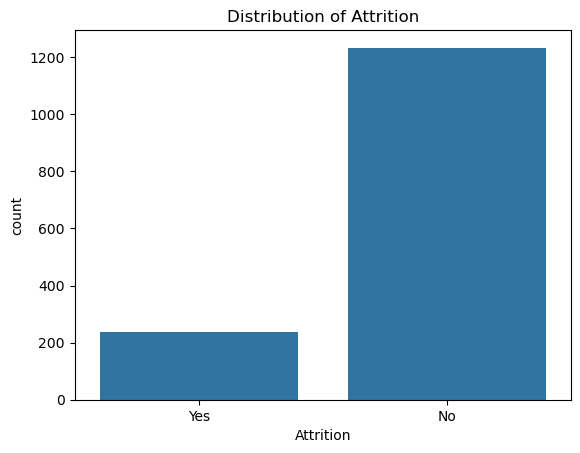

In [40]:
#Distribution of Attrition

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
sns.countplot(x='Attrition', data=df)
plt.title('Distribution of Attrition')
plt.show()

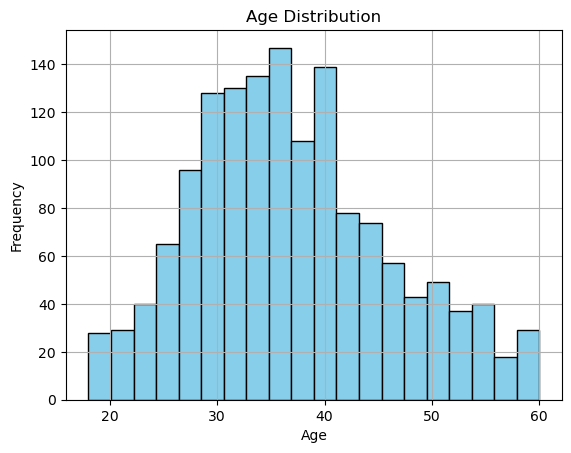

In [41]:
#Chart of Age Distribution

df['Age'].hist(bins=20, color='skyblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

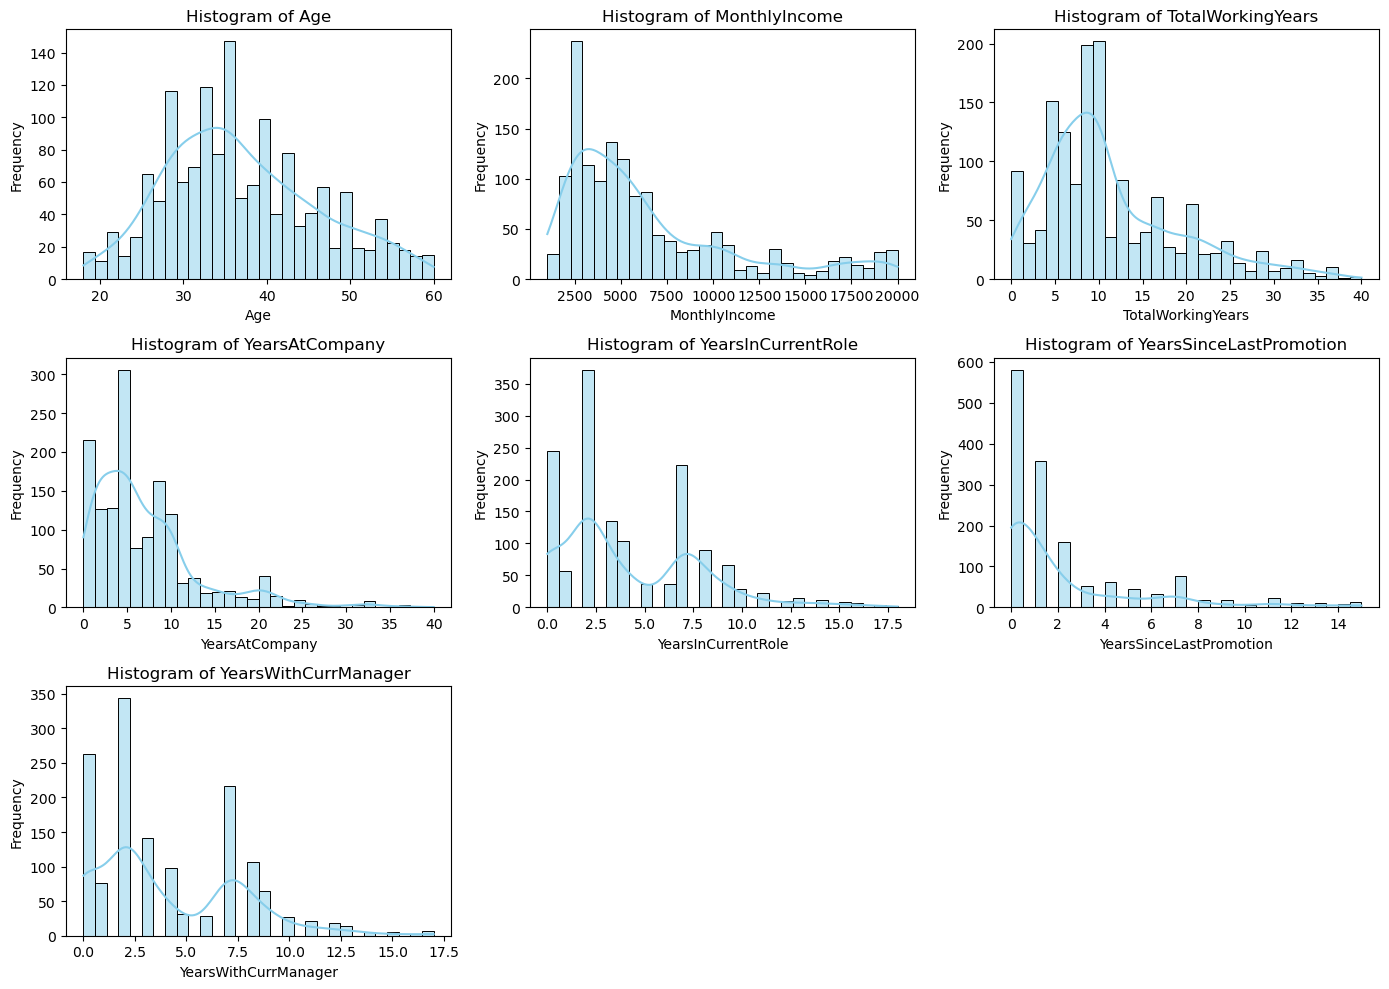

In [42]:
#histogram of numerical features

numerical_features = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

plt.figure(figsize=(14, 10))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[feature], kde=True, color='skyblue', bins=30)
    plt.title(f'Histogram of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

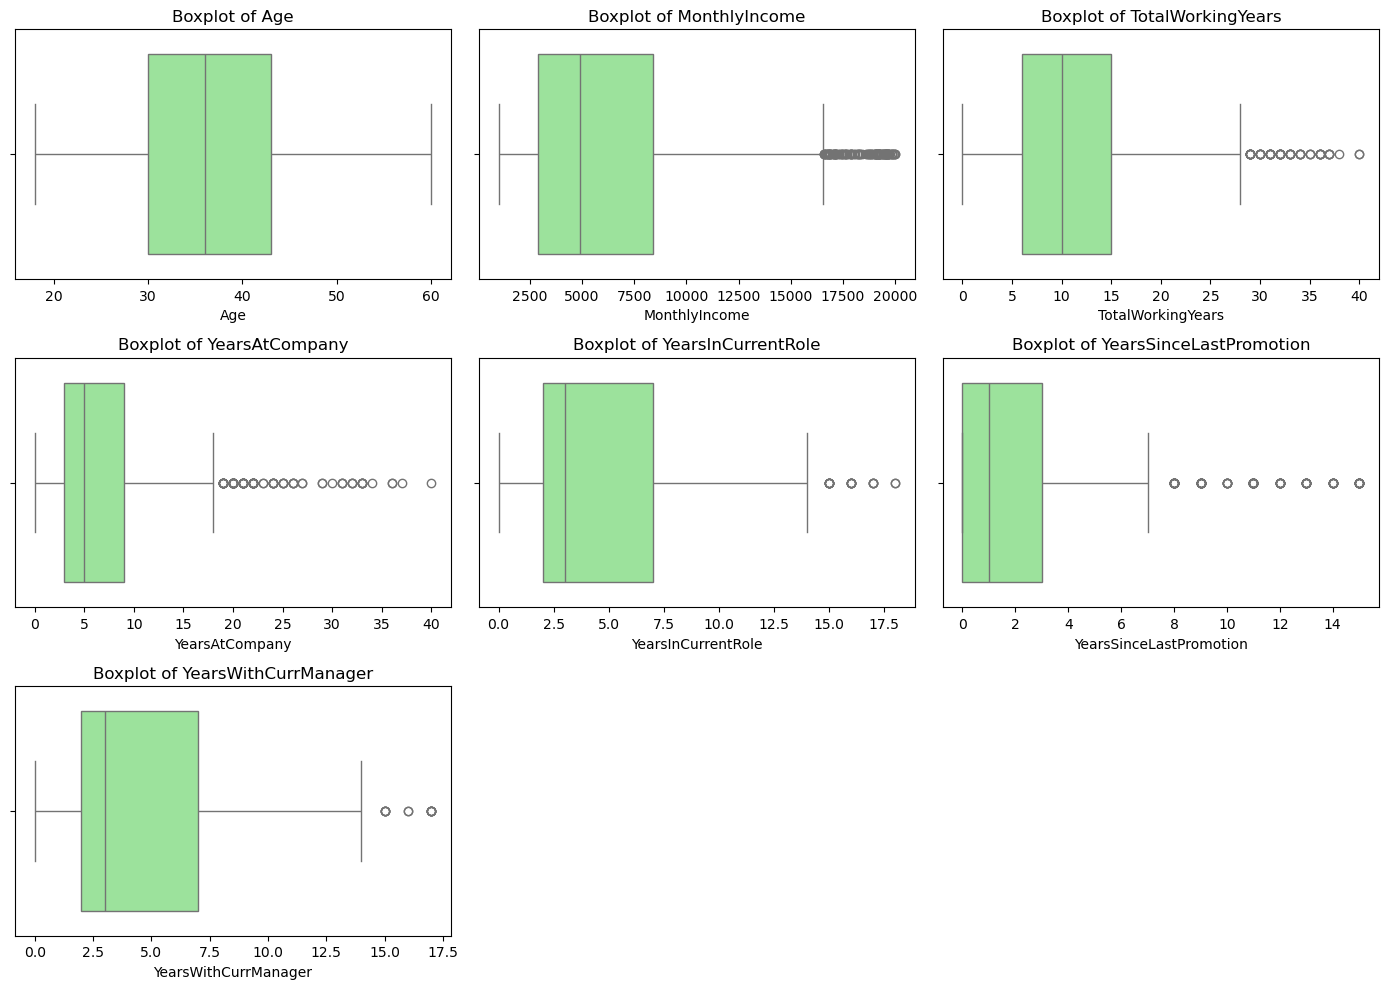

In [43]:
#boxplot of numerical features

plt.figure(figsize=(14, 10))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(3, 3, i)  # ایجاد 3x3 subplot
    sns.boxplot(x=df[feature], color='lightgreen')
    plt.title(f'Boxplot of {feature}')
    plt.xlabel(feature)

plt.tight_layout()
plt.show()

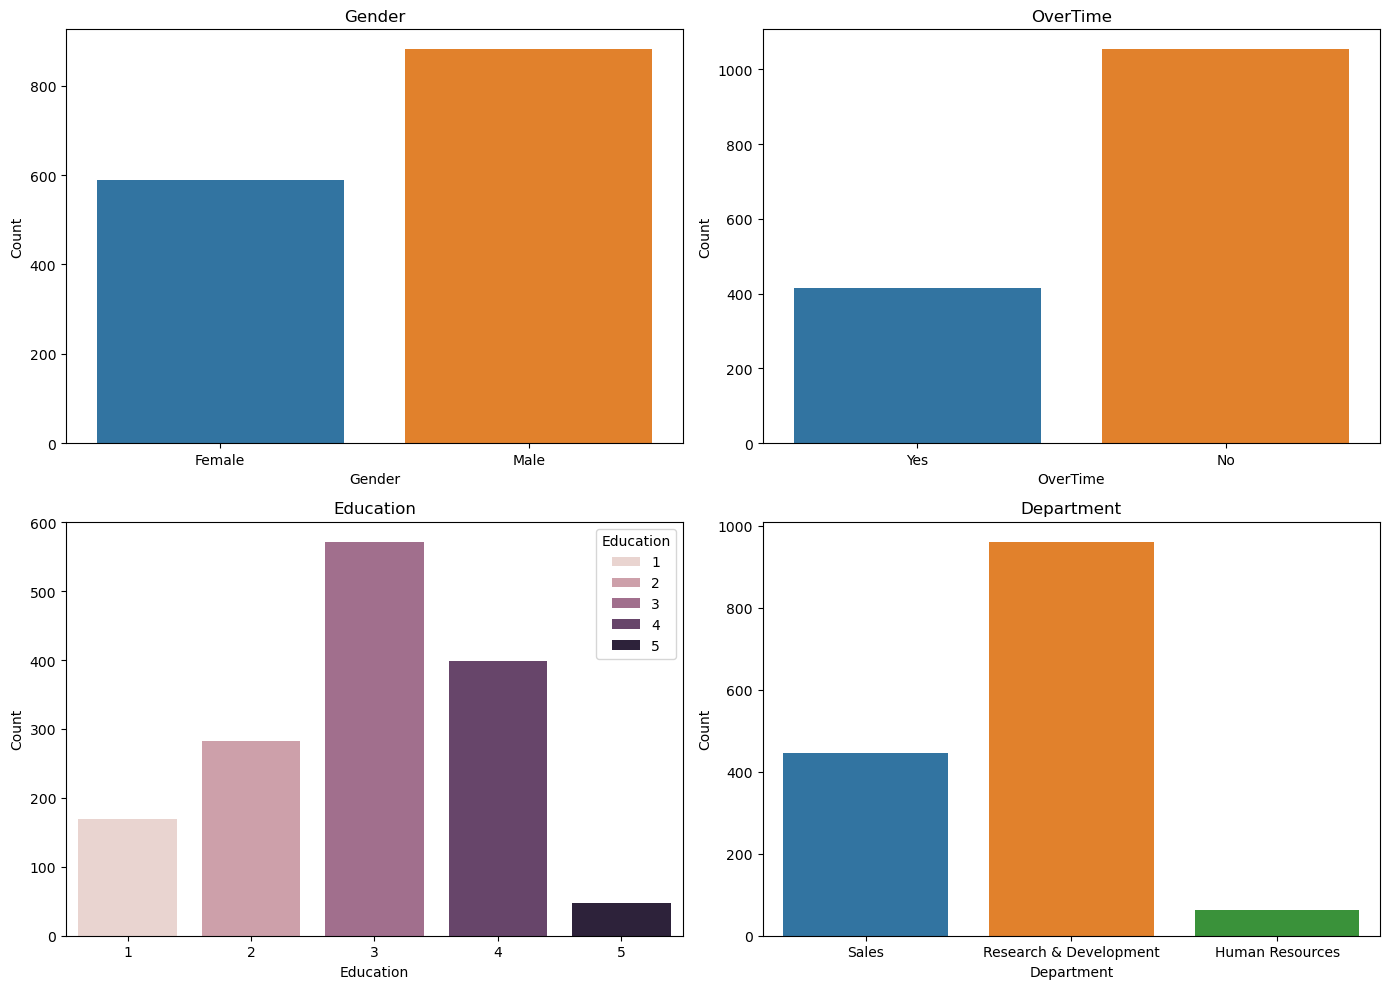

In [44]:
# barplot of categorical features

categorical_features = ['Gender', 'OverTime', 'Education', 'Department']

plt.figure(figsize=(14, 10))
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(2, 2, i)  
    sns.countplot(x=feature, data=df, hue=feature )
    plt.title(f'{feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()


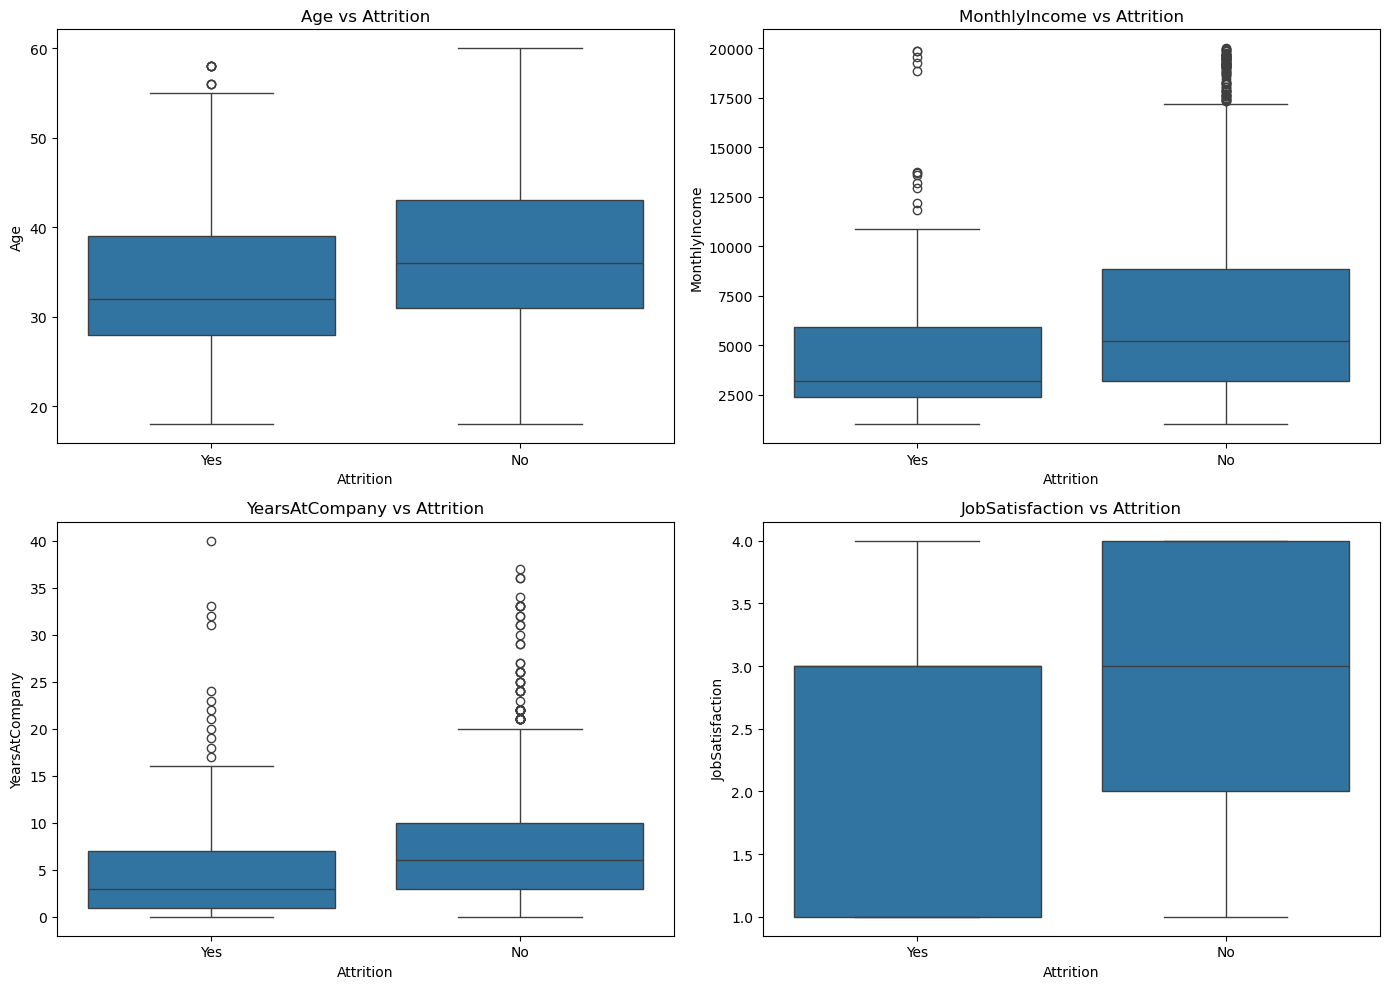

In [45]:
# some numerical features that we check and compare it with Attriton

numerical_features = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'JobSatisfaction']

plt.figure(figsize=(14, 10))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Attrition', y=feature, data=df)
    plt.title(f'{feature} vs Attrition')
    plt.xlabel('Attrition')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()


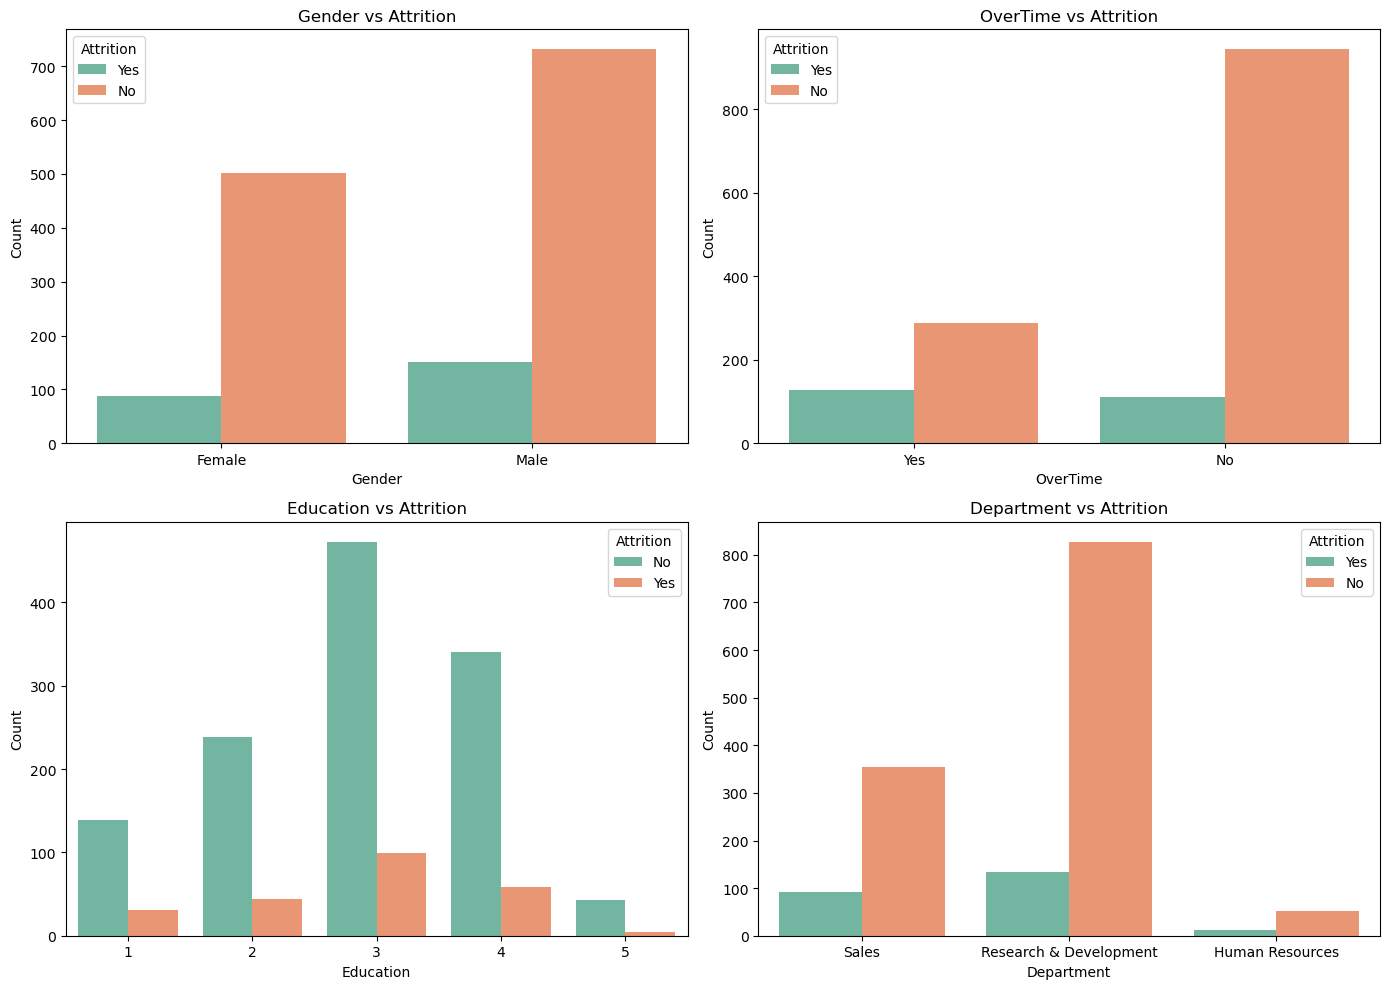

In [46]:
# some categorical features that we check and compare it with Attriton

categorical_features = ['Gender', 'OverTime', 'Education', 'Department']

plt.figure(figsize=(14, 10))
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(2, 2, i)  # ایجاد 2x2 subplot برای ویژگی‌های دسته‌ای
    sns.countplot(x=feature, hue='Attrition', data=df, palette='Set2')
    plt.title(f'{feature} vs Attrition')
    plt.xlabel(feature)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()


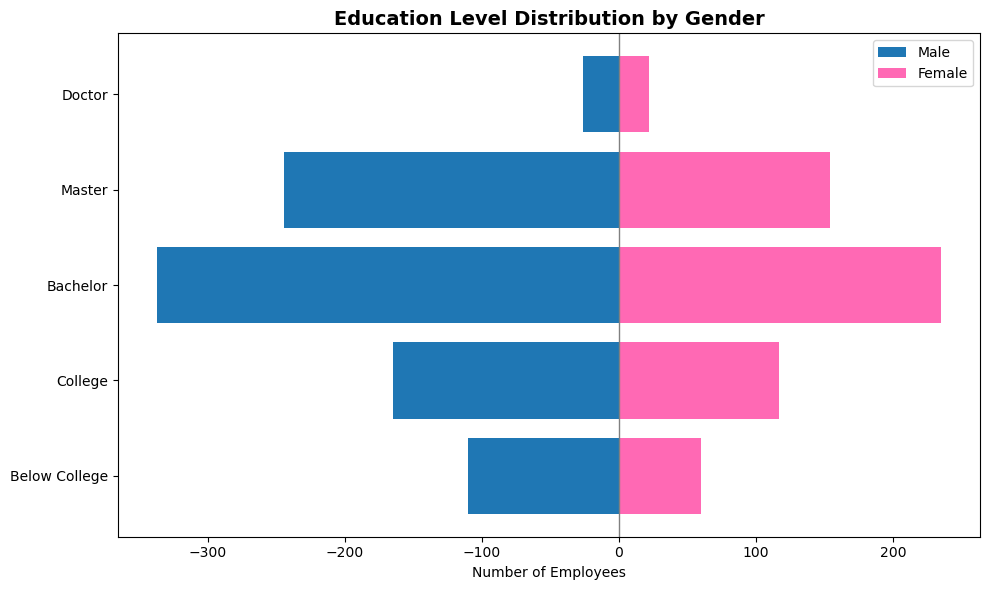

In [47]:
# pyramid chart og Education vs gender

#encoding education
education_map = {
    1: 'Below College',
    2: 'College',
    3: 'Bachelor',
    4: 'Master',
    5: 'Doctor'
}
df['EducationLabel'] = df['Education'].map(education_map)

# education/gender table
edu_gender = df.groupby(['EducationLabel', 'Gender']).size().unstack(fill_value=0)
edu_gender = edu_gender.loc[['Below College', 'College', 'Bachelor', 'Master', 'Doctor']]
edu_gender['Male'] = -edu_gender['Male']

fig, ax = plt.subplots(figsize=(10, 6))
bars_male = ax.barh(edu_gender.index, edu_gender['Male'], color='#1f77b4', label='Male')
bars_female = ax.barh(edu_gender.index, edu_gender['Female'], color='#ff69b4', label='Female')
ax.axvline(0, color='gray', linewidth=1)


for bar in bars_male:
    width = bar.get_width()
    ax.text(width - 5, bar.get_y() + bar.get_height() / 2,
            f'{abs(int(width))}', va='center', ha='right',
            color='white', fontsize=10, fontweight='bold')


ax.set_title('Education Level Distribution by Gender', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Employees')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


# Data Preprocessing

In [48]:
# find null values

df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [49]:
# find duplicates

df.duplicated().sum()

0

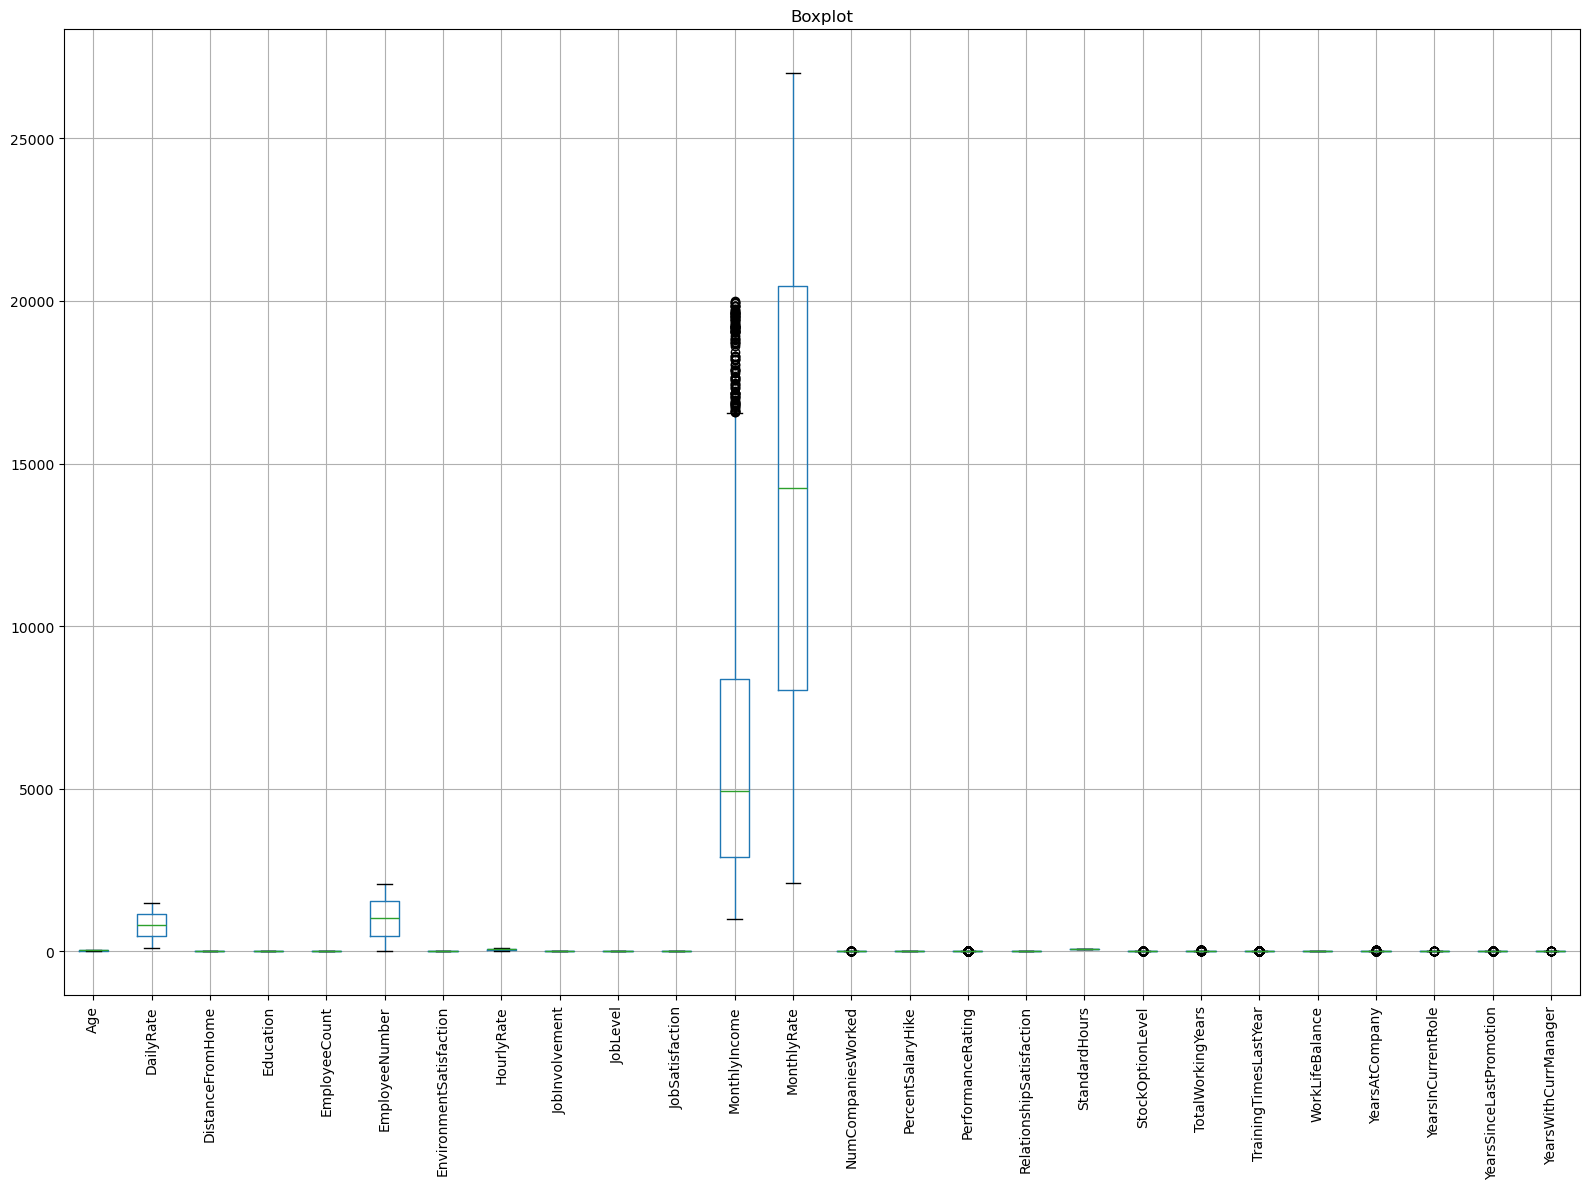

In [50]:
# find outlayers

# find numeric features
numeric_columns = df.select_dtypes(include='number').columns

# create boxplot of numeric features
plt.figure(figsize=(16, 12))
df[numeric_columns].boxplot(rot=90)
plt.title("Boxplot")
plt.grid(True)
plt.tight_layout()
plt.show()


In [51]:
#find outlayers of each feature with IQR

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outlayer")


Age: 0 outlayer
DailyRate: 0 outlayer
DistanceFromHome: 0 outlayer
Education: 0 outlayer
EmployeeCount: 0 outlayer
EmployeeNumber: 0 outlayer
EnvironmentSatisfaction: 0 outlayer
HourlyRate: 0 outlayer
JobInvolvement: 0 outlayer
JobLevel: 0 outlayer
JobSatisfaction: 0 outlayer
MonthlyIncome: 114 outlayer
MonthlyRate: 0 outlayer
NumCompaniesWorked: 52 outlayer
PercentSalaryHike: 0 outlayer
PerformanceRating: 226 outlayer
RelationshipSatisfaction: 0 outlayer
StandardHours: 0 outlayer
StockOptionLevel: 85 outlayer
TotalWorkingYears: 63 outlayer
TrainingTimesLastYear: 238 outlayer
WorkLifeBalance: 0 outlayer
YearsAtCompany: 104 outlayer
YearsInCurrentRole: 21 outlayer
YearsSinceLastPromotion: 107 outlayer
YearsWithCurrManager: 14 outlayer


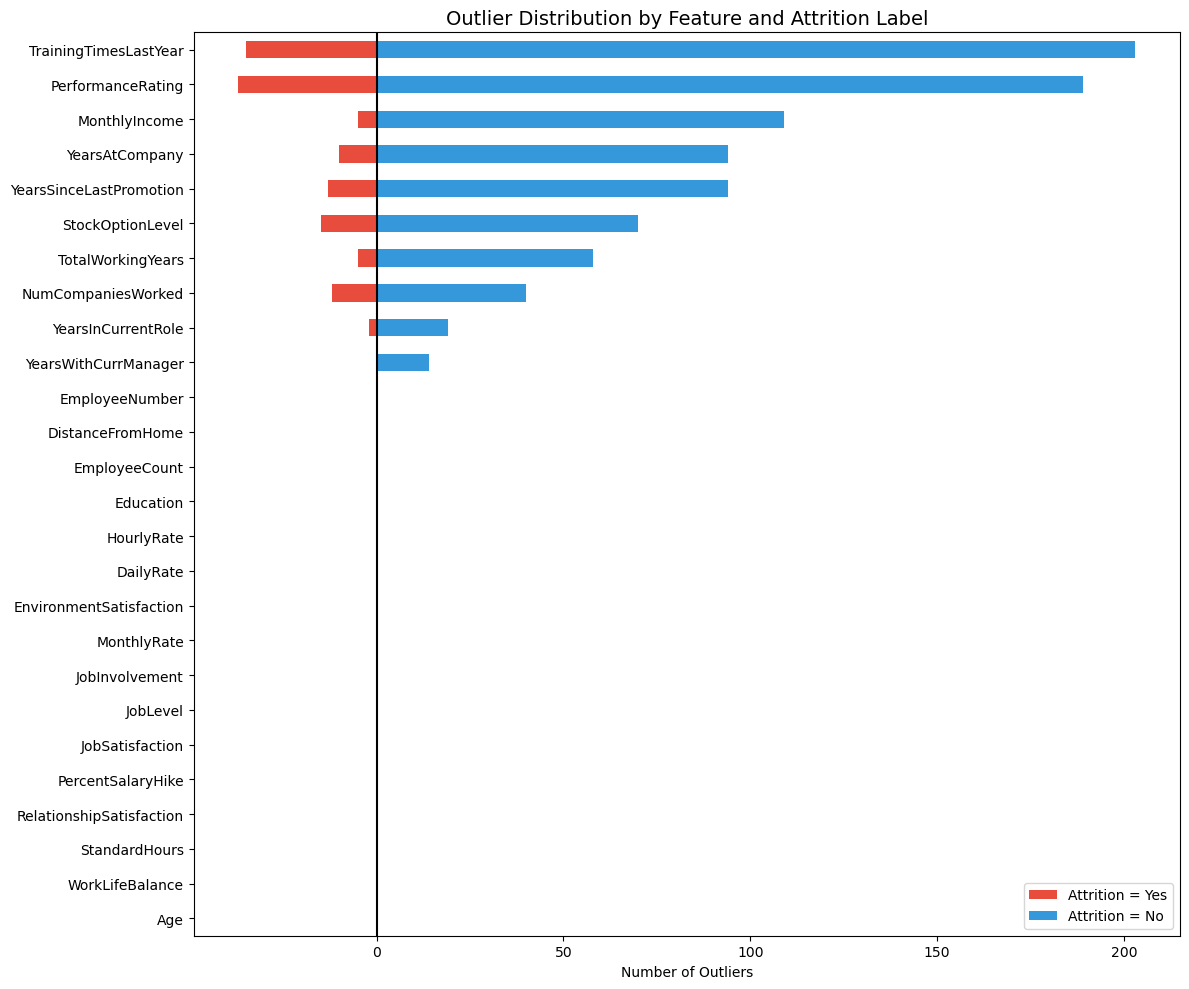

In [52]:
# filter outlayer records with attrition class

df_yes = df[df['Attrition'] == 'Yes']
df_no = df[df['Attrition'] == 'No']
numeric_cols = df.select_dtypes(include=np.number).columns

outlier_flags_yes = pd.DataFrame(0, index=df_yes.index, columns=numeric_cols)
outlier_flags_no = pd.DataFrame(0, index=df_no.index, columns=numeric_cols)

# calculate IQR
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_flags_yes[col] = ((df_yes[col] < lower) | (df_yes[col] > upper)).astype(int)
    outlier_flags_no[col] = ((df_no[col] < lower) | (df_no[col] > upper)).astype(int)

yes_counts = outlier_flags_yes.sum()
no_counts = outlier_flags_no.sum()

#create pyramid chart
outlier_pyramid = pd.DataFrame({
    'Yes': -yes_counts,  
    'No': no_counts
}).sort_values('No', ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))
outlier_pyramid['Yes'].plot(kind='barh', color='#e74c3c', label='Attrition = Yes', ax=ax)
outlier_pyramid['No'].plot(kind='barh', color='#3498db', label='Attrition = No', ax=ax)

ax.axvline(0, color='black')
ax.set_title("Outlier Distribution by Feature and Attrition Label", fontsize=14)
ax.set_xlabel("Number of Outliers")
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

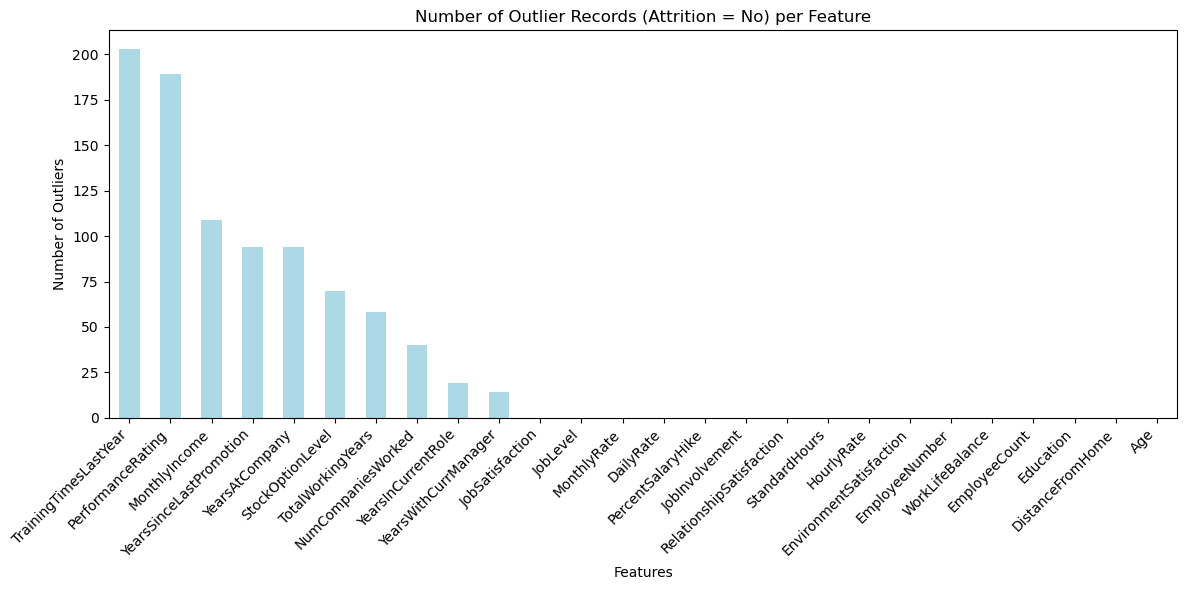

In [53]:
# Number of Outlier Records (Attrition = No) per Feature

df_no = df[df['Attrition'] == 'No']

numeric_cols = df.select_dtypes(include=np.number).columns

outlier_flags_no = pd.DataFrame(0, index=df_no.index, columns=numeric_cols)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_flags_no[col] = ((df_no[col] < lower) | (df_no[col] > upper)).astype(int)

no_outlier_count_per_feature = outlier_flags_no.sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
no_outlier_count_per_feature.plot(kind='bar', color='lightblue')
plt.title("Number of Outlier Records (Attrition = No) per Feature")
plt.xlabel("Features")
plt.ylabel("Number of Outliers")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

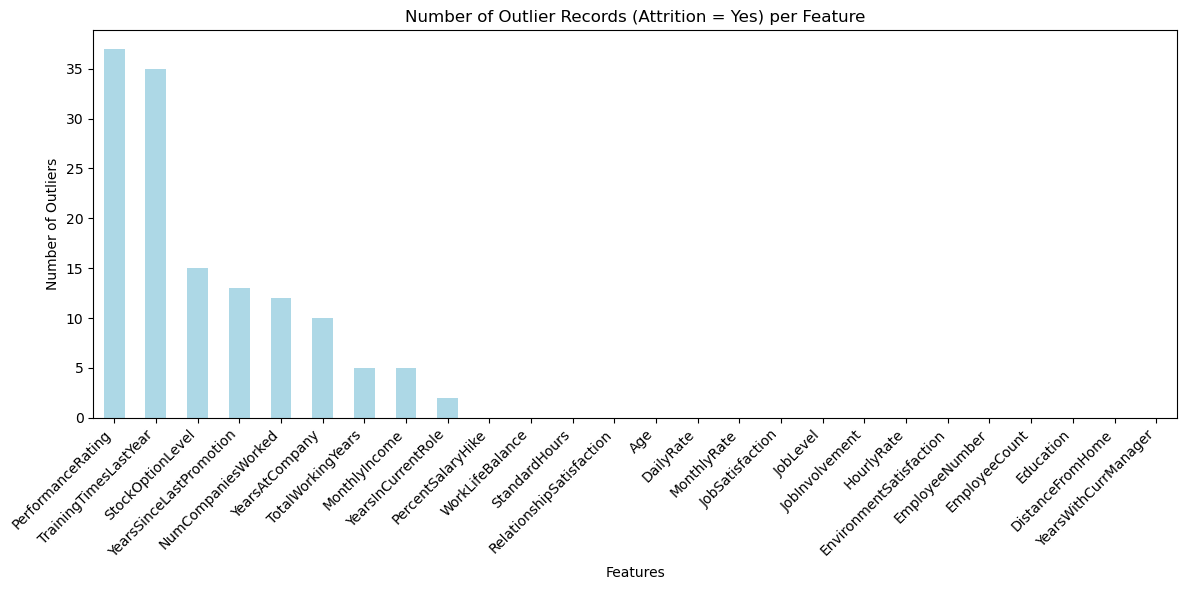

In [54]:
# Number of Outlier Records (Attrition = Yes) per Feature

df_yes = df[df['Attrition'] == 'Yes']

numeric_cols = df.select_dtypes(include=np.number).columns

outlier_flags_yes = pd.DataFrame(0, index=df_yes.index, columns=numeric_cols)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_flags_yes[col] = ((df_yes[col] < lower) | (df_yes[col] > upper)).astype(int)

yes_outlier_count_per_feature = outlier_flags_yes.sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
yes_outlier_count_per_feature.plot(kind='bar', color='lightblue')
plt.title("Number of Outlier Records (Attrition = Yes) per Feature")
plt.xlabel("Features")
plt.ylabel("Number of Outliers")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

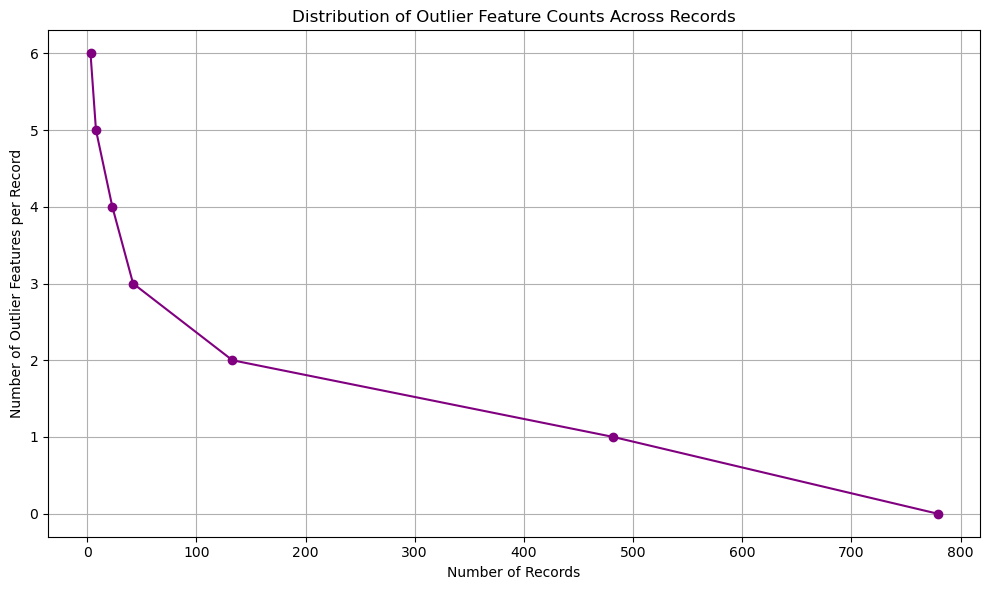

In [55]:
# Final Outlayer detection

numeric_cols = df.select_dtypes(include='number').columns
outlier_flags = pd.DataFrame(0, index=df.index, columns=numeric_cols)

# calculate IQR
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_flags[col] = ((df[col] < lower) | (df[col] > upper)).astype(int)

# Calculate count of outlayer in each record
df['OutlierFeatureCount'] = outlier_flags.sum(axis=1)

# sorting
record_outlier_counts = df['OutlierFeatureCount'].value_counts().sort_index()

# create a chart of Outlayer feature per record
plt.figure(figsize=(10, 6))
plt.plot(record_outlier_counts.values, record_outlier_counts.index, marker='o', color='purple')
plt.title("Distribution of Outlier Feature Counts Across Records")
plt.xlabel("Number of Records")
plt.ylabel("Number of Outlier Features per Record")
plt.grid(True)
plt.tight_layout()
plt.show()


In [56]:
#Count records with =>3 outlayers 

num_records_with_3_or_more_outliers = (df['OutlierFeatureCount'] >= 3).sum()
print(f"Number of records with 3 or more outlier features: {num_records_with_3_or_more_outliers}")

Number of records with 3 or more outlier features: 76


In [57]:
# delete records with =>3 outlayers
df_cleaned = df[df['OutlierFeatureCount'] < 3].copy()

df_cleaned = df_cleaned.drop(columns=['OutlierFeatureCount'])

# create new datasetof dataset without outlayers
df_cleaned.to_csv('cleaned_hr_dataset.csv', index=False)

# Feature selection

In [58]:
# read new dataset

df = pd.read_csv('cleaned_hr_dataset.csv')

In [59]:
# Check types of feature

df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [60]:
# Delete low variance columns(with 1 value)

temp = []
for col in df.columns:
    if len(df[col].unique()) == 1:
        temp.append(col)
        df.drop(col, inplace=True, axis=1)

print(f"Deleted columns: {temp}")

Deleted columns: ['EmployeeCount', 'Over18', 'StandardHours']


In [61]:
# Delete EmployeeNumber column

df.drop(['EmployeeNumber'], axis = 1, inplace = True)

Attrition                   1.000000
DistanceFromHome            0.078120
NumCompaniesWorked          0.050625
PerformanceRating           0.015789
MonthlyRate                 0.011005
PercentSalaryHike          -0.001659
HourlyRate                 -0.005854
YearsSinceLastPromotion    -0.010683
Education                  -0.027885
RelationshipSatisfaction   -0.049487
DailyRate                  -0.054967
TrainingTimesLastYear      -0.056721
WorkLifeBalance            -0.065311
EnvironmentSatisfaction    -0.107055
JobSatisfaction            -0.117037
JobInvolvement             -0.133120
StockOptionLevel           -0.136209
YearsAtCompany             -0.142787
YearsWithCurrManager       -0.147925
MonthlyIncome              -0.151960
Age                        -0.153643
JobLevel                   -0.162216
YearsInCurrentRole         -0.165598
TotalWorkingYears          -0.171038
Name: Attrition, dtype: float64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_9128\1664344416.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='coolwarm')


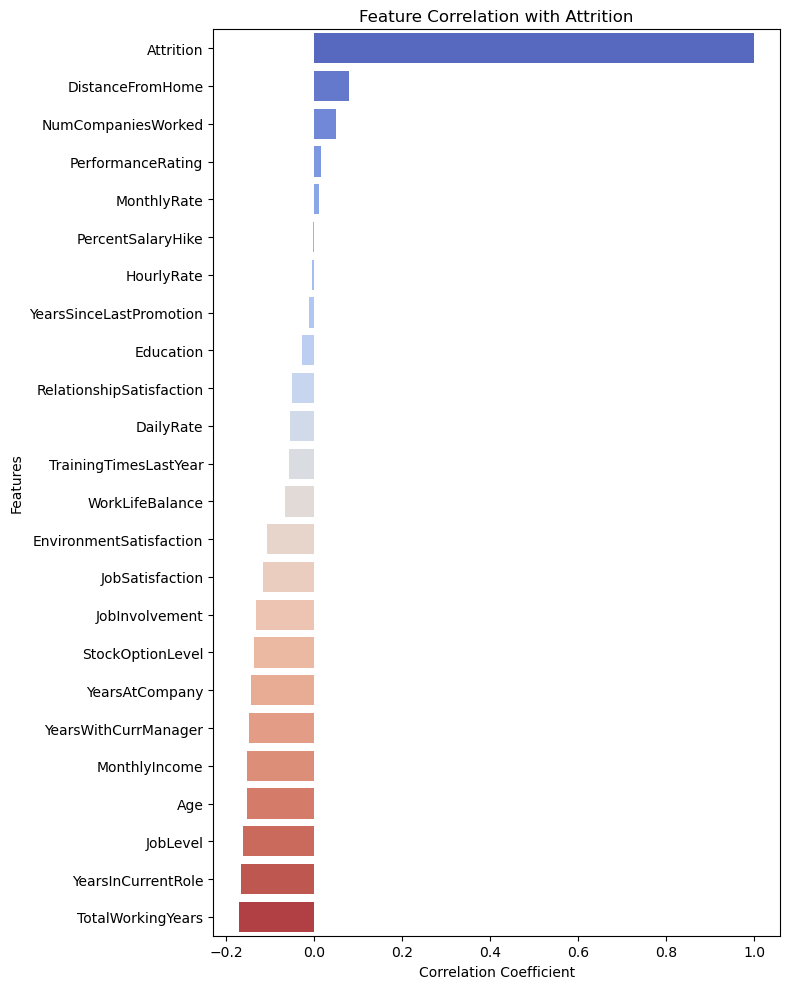

In [62]:
# Calculate feature corrolation with attrition

df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
numeric_df = df.select_dtypes(include=[float, int])

corr_with_target = numeric_df.corr()['Attrition'].sort_values(ascending=False)


print(corr_with_target)

plt.figure(figsize=(8, 10))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='coolwarm')
plt.title('Feature Correlation with Attrition')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


In [63]:
# Caculate corrolation matrix
corr_matrix = numeric_df.corr()

# display features with high corrolation
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            colname1 = corr_matrix.columns[i]
            colname2 = corr_matrix.columns[j]
            corr_value = corr_matrix.iloc[i, j]
            high_corr_pairs.append((colname1, colname2, corr_value))


for item in high_corr_pairs:
    print(f"{item[0]} and {item[1]}: Correlation = {item[2]:.2f}")


MonthlyIncome and JobLevel: Correlation = 0.94
YearsWithCurrManager and YearsAtCompany: Correlation = 0.80


<Axes: >

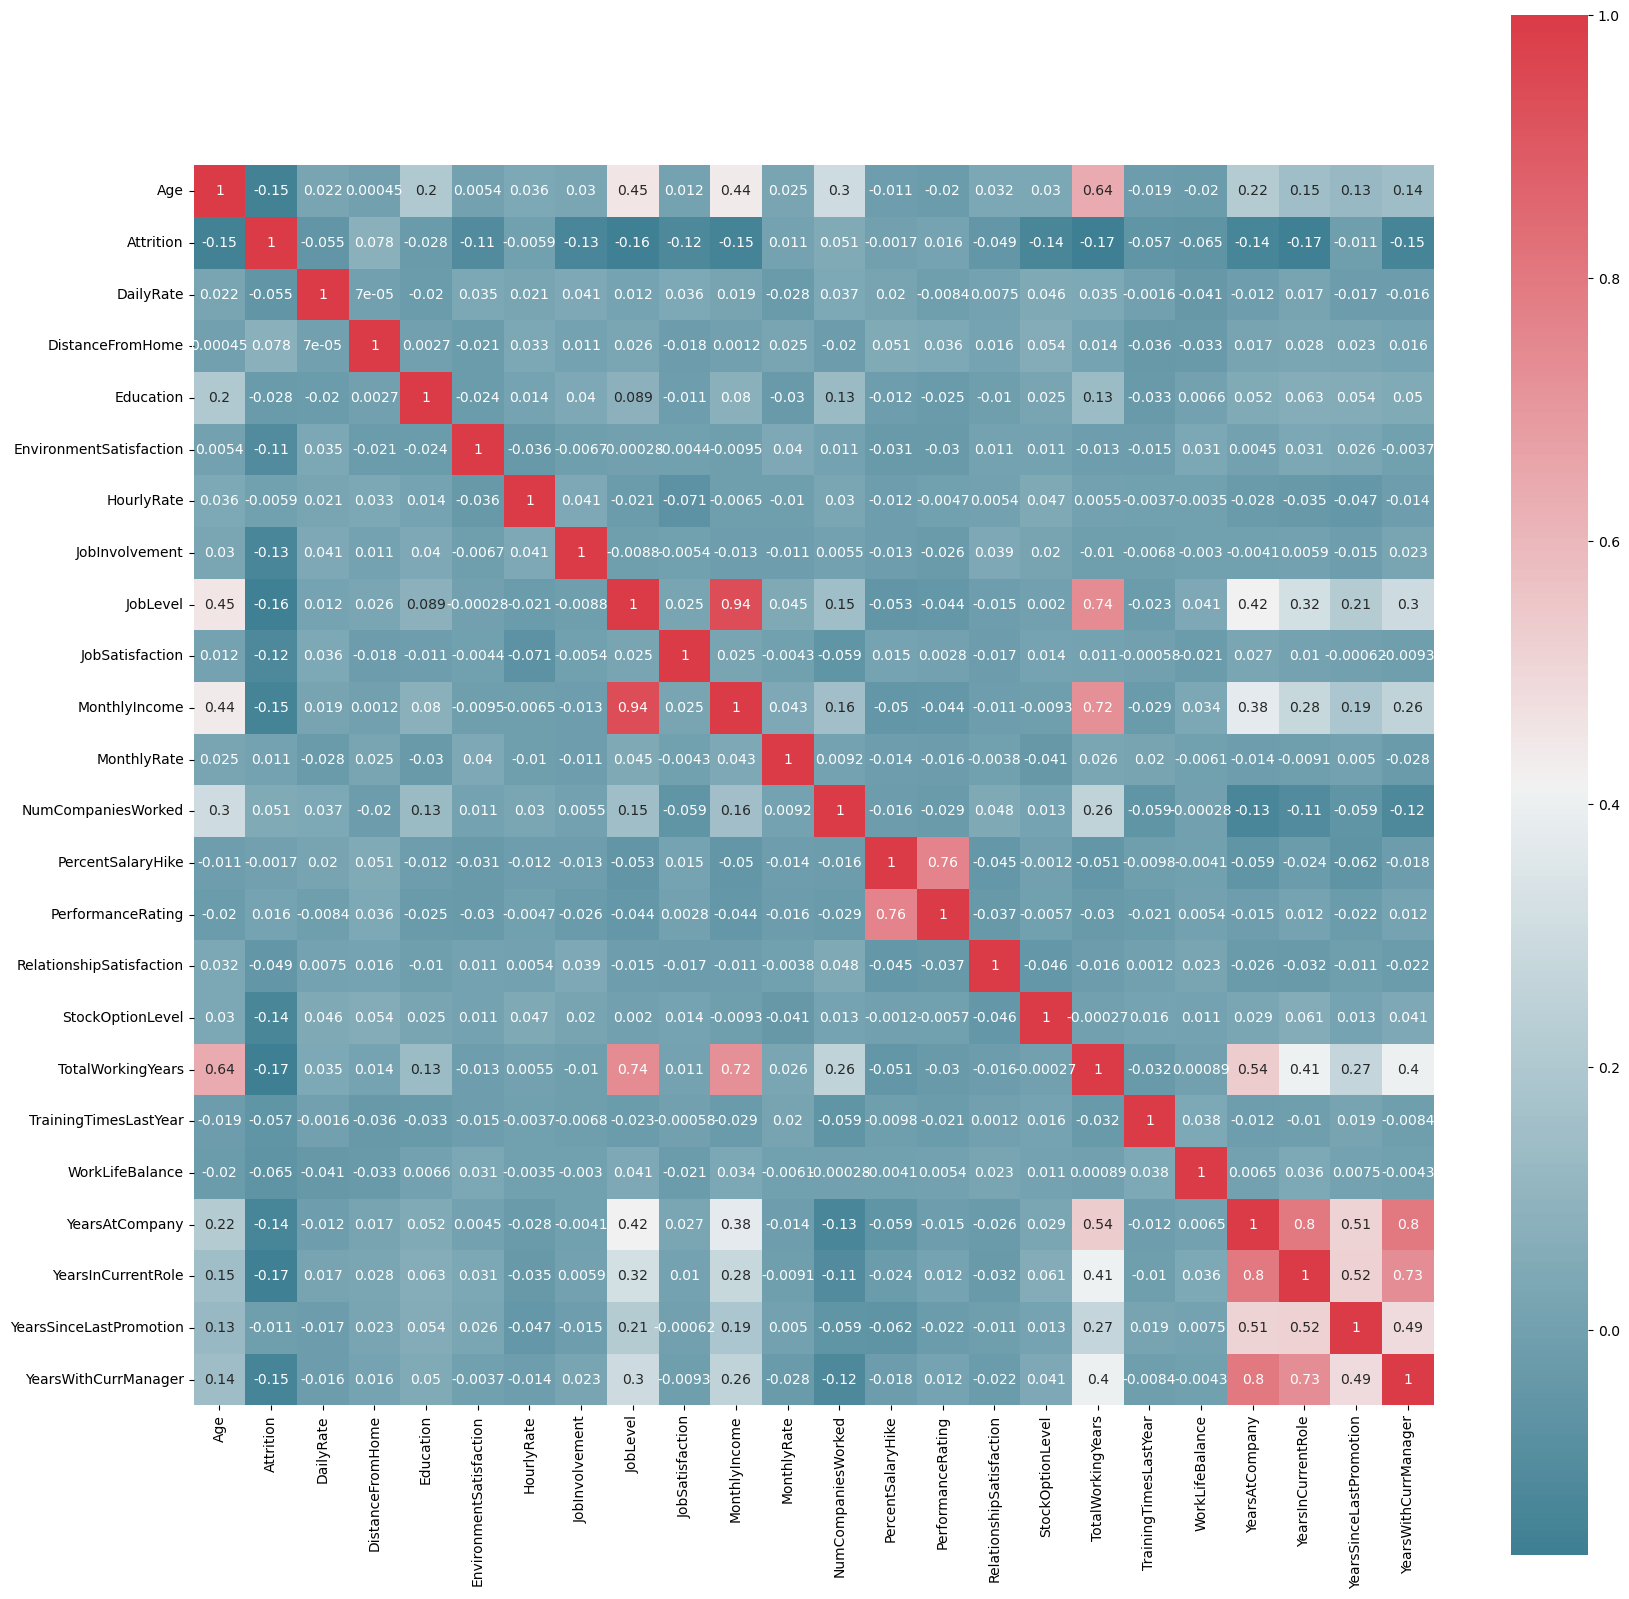

In [64]:
# display corrolation heatmap

f, ax = plt.subplots(figsize=(20, 20))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, mask=np.zeros_like(corr), cmap=sns.diverging_palette(220, 10, as_cmap=True),
            square=True, ax=ax, annot = True)

# Encoding

In [65]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# one-hot encoding on categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

print(f"✅ feature count befor encoding: {X.shape[1]}")
print(f"✅ feature count after encoding: {X_encoded.shape[1]}")


✅ feature count befor encoding: 31
✅ feature count after encoding: 48


# Normalization

In [66]:
from sklearn.preprocessing import StandardScaler

# create a copy for normalization
X_scaled = X_encoded.copy()

scaler = StandardScaler()
X_scaled[X_scaled.columns] = scaler.fit_transform(X_scaled)

print(X_scaled.head())
df_final = pd.concat([pd.DataFrame(X_scaled, columns=X_encoded.columns), y.reset_index(drop=True)], axis=1)

# save as CSV
df_final.to_csv("processed_hr_dataset.csv", index=False)

print("✅ processed_hr_dataset.csv saved")


        Age  DailyRate  DistanceFromHome  Education  EnvironmentSatisfaction  \
0  0.524393   0.740727         -1.021961  -0.884214                -0.659433   
1  1.424089  -1.303619         -0.153975  -1.866361                 0.256154   
2  0.074544   1.413896         -0.897963  -0.884214                 1.171741   
3 -0.375304   1.461093         -0.773965   1.080080                 1.171741   
4 -1.050076  -0.528606         -0.897963  -1.866361                -1.575020   

   HourlyRate  JobInvolvement  JobLevel  JobSatisfaction  MonthlyIncome  ...  \
0    1.380480        0.379934  0.052724         1.142600       0.005243  ...   
1   -0.244973       -1.028650  0.052724        -0.674610      -0.204150  ...   
2    1.281968       -1.028650 -0.954096         0.233995      -0.941757  ...   
3   -0.491254        0.379934 -0.954096         0.233995      -0.743040  ...   
4   -1.279353        0.379934 -0.954096        -0.674610      -0.607408  ...   

   JobRole_Research Scientist  JobRole

# Feature selection

Optimal number of features: 47
Selected Features:
Index(['Age', 'DailyRate', 'DistanceFromHome', 'EnvironmentSatisfaction',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'Gender_Male',
       'JobRole_Human Resources', 'JobRole_Laboratory Technician',
       'JobRole_Manager', 'JobRole_Manufacturing Director',
       'JobRole_Research

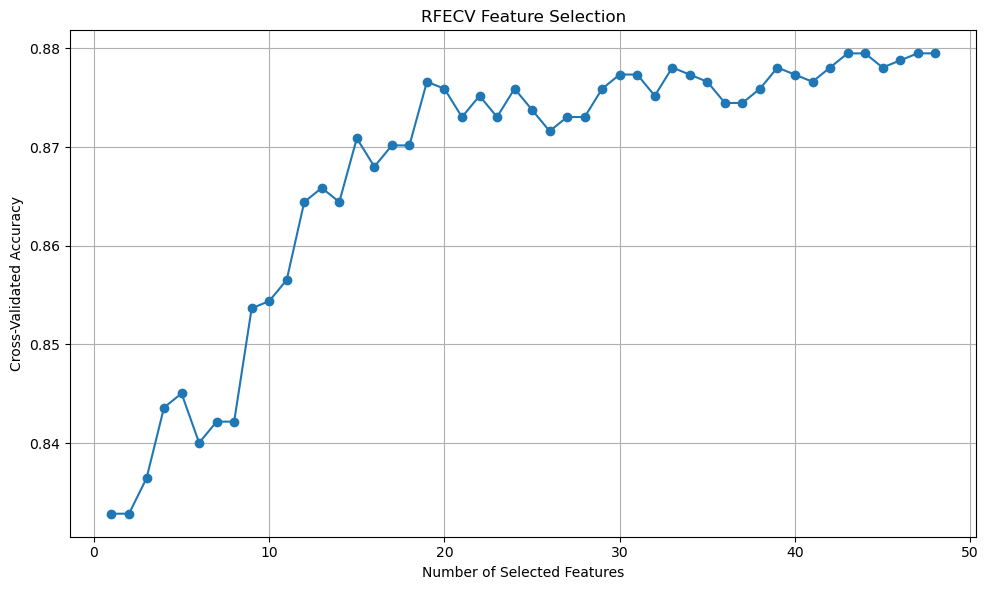

In [70]:
# RFECV Feature selection

from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

df = pd.read_csv("processed_hr_dataset.csv")

X = df.drop('Attrition', axis=1)
y = df['Attrition']

model = LogisticRegression(solver='liblinear', max_iter=1000)
cv = StratifiedKFold(n_splits=5)

rfecv = RFECV(estimator=model, step=1, cv=cv, scoring='accuracy')
rfecv.fit(X, y)

print("Optimal number of features:", rfecv.n_features_)
print("Selected Features:")
print(X.columns[rfecv.support_])

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(rfecv.cv_results_["mean_test_score"]) + 1),
         rfecv.cv_results_["mean_test_score"], marker='o')
plt.xlabel("Number of Selected Features")
plt.ylabel("Cross-Validated Accuracy")
plt.title("RFECV Feature Selection")
plt.grid(True)
plt.tight_layout()
plt.show()


✅ Optimal number of features: 29


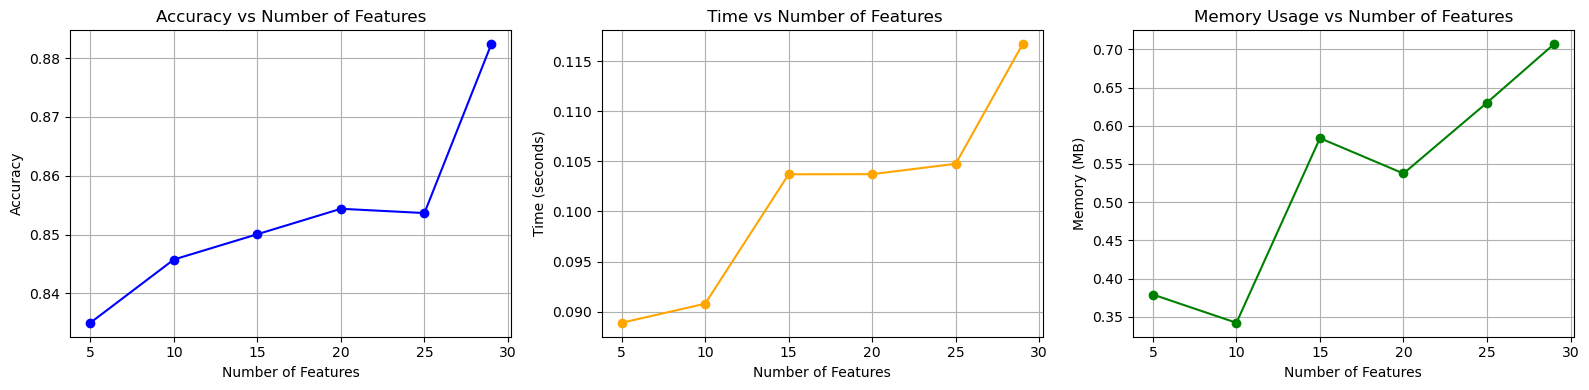

In [72]:
# Accuracy, Time and memory usage vs feature count
import time
import tracemalloc
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler

data = pd.read_csv("processed_hr_dataset.csv")

X = data.drop("Attrition", axis=1)
y = data["Attrition"]

model = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfecv = RFECV(estimator=model, step=1, cv=cv, scoring='accuracy', n_jobs=-1)
rfecv.fit(X, y)

print("✅ Optimal number of features:", rfecv.n_features_)

ranking = pd.Series(rfecv.ranking_, index=X.columns)
top_features_sorted = ranking[ranking == 1].index.tolist()
total_top_features = len(top_features_sorted)

step = 5
feature_counts = list(range(step, total_top_features, step))
if total_top_features not in feature_counts:
    feature_counts.append(total_top_features)

accuracies = []
times = []
memories = []

for n_features in feature_counts:
    selected = top_features_sorted[:n_features]
    X_subset = X[selected]

    start_time = time.time()
    tracemalloc.start()

    scores = cross_val_score(model, X_subset, y, cv=cv, scoring='accuracy')
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    end_time = time.time()

    accuracies.append(scores.mean())
    times.append(end_time - start_time)
    memories.append(peak / 1024 / 1024)  

plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
plt.plot(feature_counts, accuracies, marker='o', color='blue')
plt.title("Accuracy vs Number of Features")
plt.xlabel("Number of Features")
plt.ylabel("Accuracy")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(feature_counts, times, marker='o', color='orange')
plt.title(" Time vs Number of Features")
plt.xlabel("Number of Features")
plt.ylabel("Time (seconds)")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(feature_counts, memories, marker='o', color='green')
plt.title("Memory Usage vs Number of Features")
plt.xlabel("Number of Features")
plt.ylabel("Memory (MB)")
plt.grid(True)

plt.tight_layout()
plt.show()

✅ Optimal number of features: 29


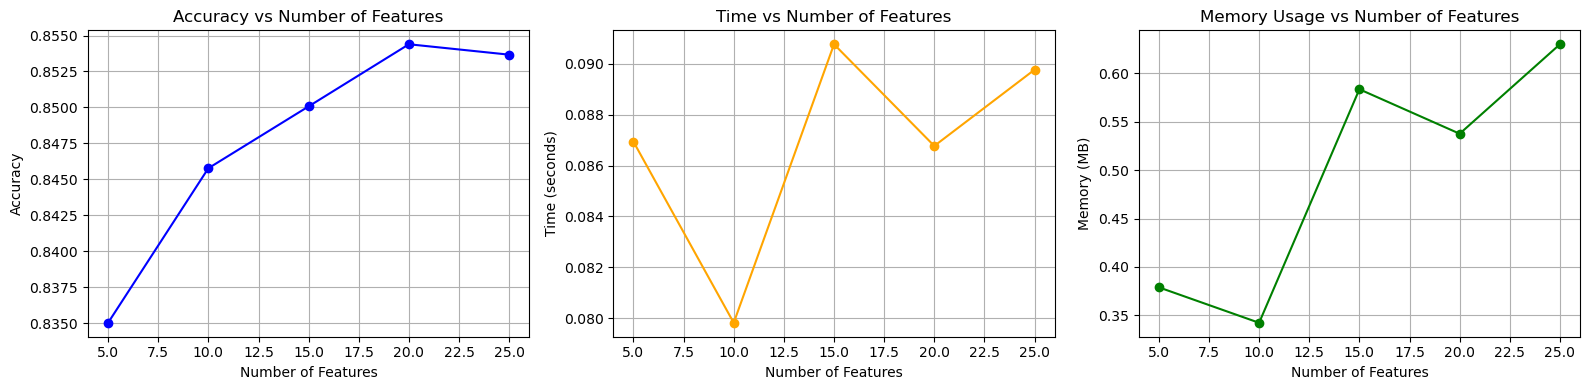

In [73]:
# Accuracy, Time and memory usage vs feature count
X = data.drop("Attrition", axis=1)
y = data["Attrition"]

model = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfecv = RFECV(estimator=model, step=1, cv=cv, scoring='accuracy', n_jobs=-1)
rfecv.fit(X, y)

print("✅ Optimal number of features:", rfecv.n_features_)

ranking = pd.Series(rfecv.ranking_, index=X.columns)
top_features_sorted = ranking[ranking == 1].index.tolist()

step = 5
max_feat = len(top_features_sorted)
feature_counts = list(range(step, max_feat + 1, step))

accuracies = []
times = []
memories = []

for n_features in feature_counts:
    selected = top_features_sorted[:n_features]
    X_subset = X[selected]

    start_time = time.time()
    tracemalloc.start()

    scores = cross_val_score(model, X_subset, y, cv=cv, scoring='accuracy')
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    end_time = time.time()

    accuracies.append(scores.mean())
    times.append(end_time - start_time)
    memories.append(peak / 1024 / 1024)  


plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
plt.plot(feature_counts, accuracies, marker='o', color='blue')
plt.title("Accuracy vs Number of Features")
plt.xlabel("Number of Features")
plt.ylabel("Accuracy")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(feature_counts, times, marker='o', color='orange')
plt.title("Time vs Number of Features")
plt.xlabel("Number of Features")
plt.ylabel("Time (seconds)")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(feature_counts, memories, marker='o', color='green')
plt.title("Memory Usage vs Number of Features")
plt.xlabel("Number of Features")
plt.ylabel("Memory (MB)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [74]:
X = data.drop("Attrition", axis=1)
y = data["Attrition"]

# RFECV
model = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rfecv = RFECV(estimator=model, step=1, cv=cv, scoring='accuracy', n_jobs=-1)
rfecv.fit(X, y)

# select 19 top features
ranking = pd.Series(rfecv.ranking_, index=X.columns)
top_features_sorted = ranking[ranking == 1].index.tolist()[:19]


final_selected_df = X[top_features_sorted].copy()
final_selected_df["Attrition"] = y

# save
final_selected_df.to_csv("final_selected_19_features_dataset.csv", index=False)

# Machin Learning

Accuracy: 0.8566308243727598
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.97      0.92       232
           1       0.68      0.28      0.39        47

    accuracy                           0.86       279
   macro avg       0.78      0.63      0.66       279
weighted avg       0.84      0.86      0.83       279

Confusion Matrix:
 [[226   6]
 [ 34  13]]
ROC-AUC Score: 0.7983308877476155


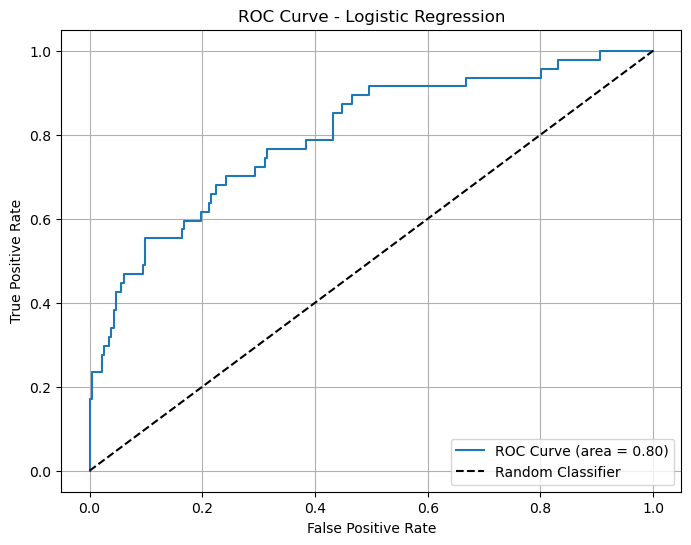

In [77]:
#logestic regression

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

# read final data
df = pd.read_csv("final_selected_19_features_dataset.csv") 

# split data
X = df.drop("Attrition", axis=1)
y = df["Attrition"]
# create test and train 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# learning model
model = LogisticRegression(solver='liblinear')
model.fit(X_train, y_train)

# predic
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label="ROC Curve (area = %0.2f)" % roc_auc_score(y_test, y_prob))
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Best k: 9 with CV accuracy: 0.8386


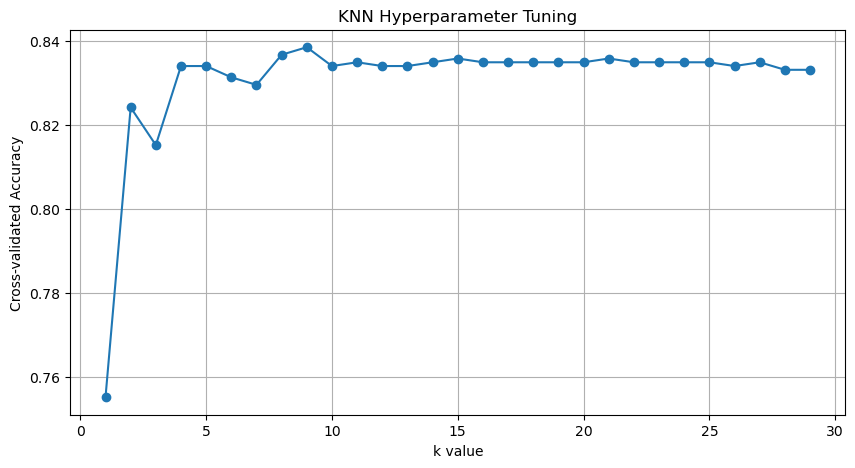

In [79]:
# select optimal k for knn

from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

k_range = range(1, 30)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

optimal_k = k_range[cv_scores.index(max(cv_scores))]
print(f"Best k: {optimal_k} with CV accuracy: {max(cv_scores):.4f}")

plt.figure(figsize=(10, 5))
plt.plot(k_range, cv_scores, marker='o')
plt.xlabel('k value')
plt.ylabel('Cross-validated Accuracy')
plt.title('KNN Hyperparameter Tuning')
plt.grid(True)
plt.show()

Accuracy: 0.8458781362007168

 Classification Report:
               precision    recall  f1-score   support

           0       0.84      1.00      0.92       232
           1       1.00      0.09      0.16        47

    accuracy                           0.85       279
   macro avg       0.92      0.54      0.54       279
weighted avg       0.87      0.85      0.79       279


 Confusion Matrix:
 [[232   0]
 [ 43   4]]
ROC-AUC Score: 0.6746148202494497


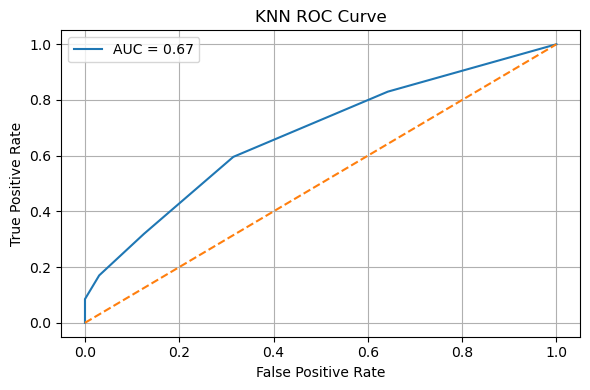

In [81]:
#KNN Model

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
y_prob = knn.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\n Classification Report:\n", classification_report(y_test, y_pred))
print("\n Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Accuracy: 0.8566308243727598

 Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.99      0.92       232
           1       0.77      0.21      0.33        47

    accuracy                           0.86       279
   macro avg       0.82      0.60      0.63       279
weighted avg       0.85      0.86      0.82       279


 Confusion Matrix:
 [[229   3]
 [ 37  10]]
ROC-AUC Score: 0.77242296404989


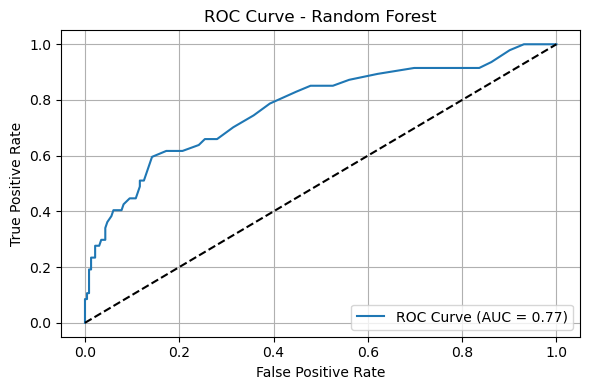

In [83]:
# Random forest model
from sklearn.ensemble import RandomForestClassifier

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

# Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)


y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\n Classification Report:\n", classification_report(y_test, y_pred))
print("\n Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_prob):.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

Accuracy: 0.7813620071684588

 Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.81      0.86       232
           1       0.41      0.64      0.50        47

    accuracy                           0.78       279
   macro avg       0.66      0.72      0.68       279
weighted avg       0.83      0.78      0.80       279


 Confusion Matrix:
 [[188  44]
 [ 17  30]]
ROC-AUC Score: 0.7698092443140132


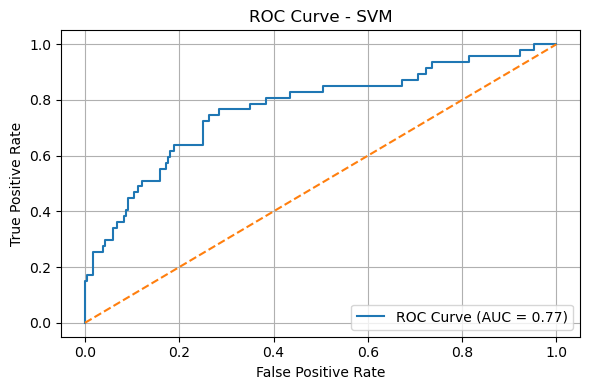

In [85]:
# SVM Model with feature selection

from sklearn.svm import SVC

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

svm = SVC(probability=True, kernel='rbf', class_weight='balanced', random_state=42)
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
y_prob = svm.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\n Classification Report:\n", classification_report(y_test, y_pred))
print("\n Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_prob):.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

Accuracy: 0.8422939068100358

 Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.89      0.90       232
           1       0.53      0.62      0.57        47

    accuracy                           0.84       279
   macro avg       0.72      0.75      0.74       279
weighted avg       0.85      0.84      0.85       279


 Confusion Matrix:
 [[206  26]
 [ 18  29]]
ROC-AUC Score: 0.774303008070433


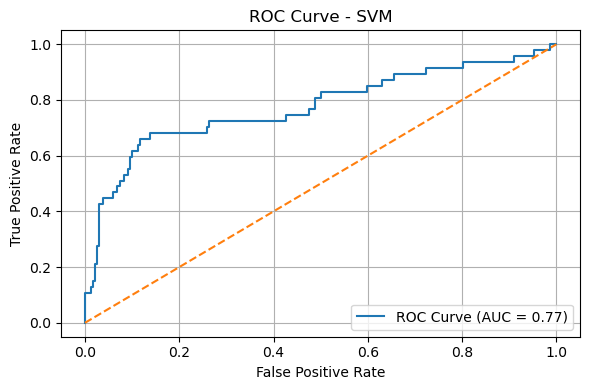

In [33]:
# SVM Without feature selection

df = pd.read_csv("processed_hr_dataset.csv")  

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# SVM model
svm = SVC(probability=True, kernel='rbf', class_weight='balanced', random_state=42)
svm.fit(X_train, y_train)


y_pred = svm.predict(X_test)
y_prob = svm.predict_proba(X_test)[:, 1]


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\n Classification Report:\n", classification_report(y_test, y_pred))
print("\n Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, y_prob):.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Data Visualization 
including dimension reduction using PCA


In [4]:
df = pd.read_csv("final_selected_19_features_dataset.csv")  

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [7]:
# Importing PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
pca.fit(X_train)
x_train_pca = pca.transform(X_train)

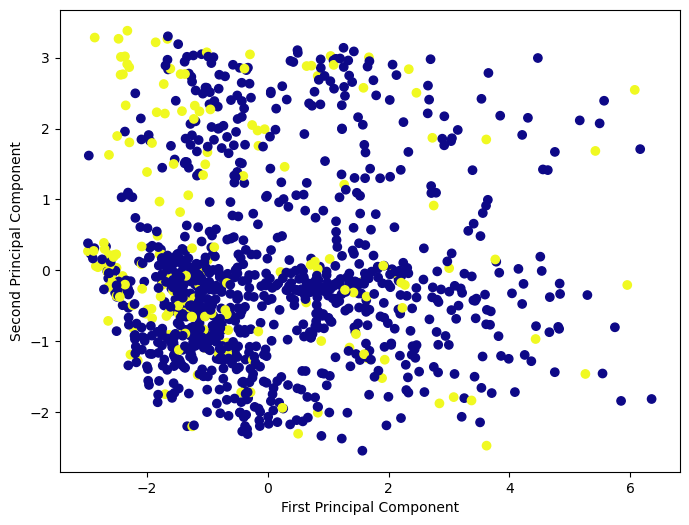

In [8]:
#

plt.figure(figsize=(8, 6))

plt.scatter(x_train_pca[:, 0], x_train_pca[:, 1],
            c=y_train,
            cmap='plasma')

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.show()

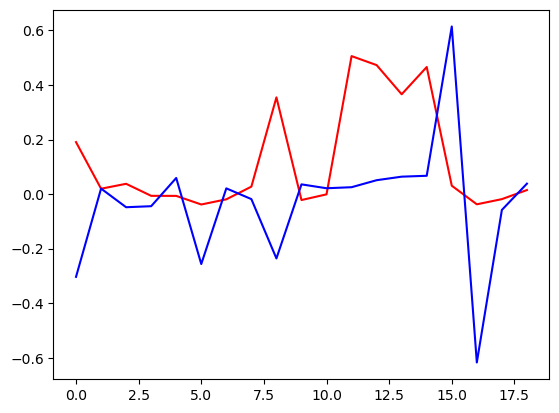

In [9]:
#
plt.plot(pca.components_[0],'r')
plt.plot(pca.components_[1],'b')
plt.show()

In [10]:
from sklearn.manifold import TSNE

# Initialize and fit t-SNE
tsne = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=0.005)
X_embedded = tsne.fit_transform(X)

print(X_embedded.shape)

(1394, 2)


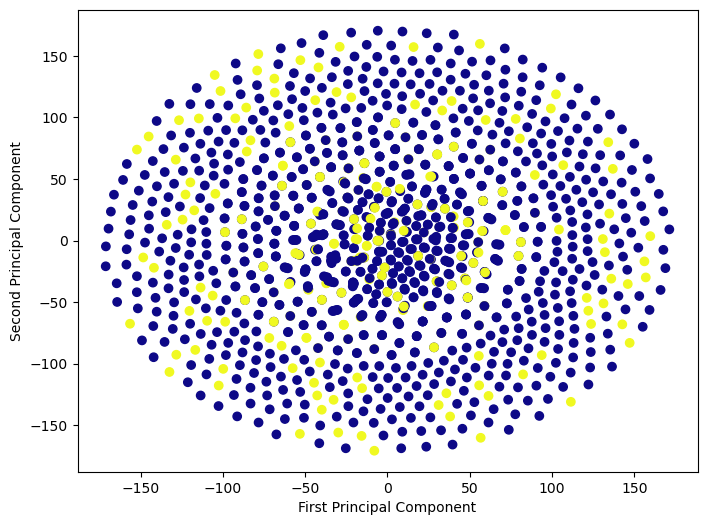

In [11]:
# giving a larger plot
plt.figure(figsize=(8, 6))

plt.scatter(X_embedded[:, 0], X_embedded[:, 1],
            c=y,
            cmap='plasma')

# labeling x and y axes
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.show()

# imbalanced learning

In [12]:
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import cross_validate

ebb = BaggingClassifier()
cv_results = cross_validate(ebb, X_train, y_train, scoring="balanced_accuracy")

print(f"{cv_results['test_score'].mean():.3f} +/- {cv_results['test_score'].std():.3f}")

0.556 +/- 0.027


In [15]:
from imblearn.ensemble import BalancedBaggingClassifier
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
# Exactly Balanced Bagging
ebb = BalancedBaggingClassifier(sampler=RandomUnderSampler())
cv_results = cross_validate(ebb,X_train, y_train, scoring="balanced_accuracy")

print(f"{cv_results['test_score'].mean():.3f} +/- {cv_results['test_score'].std():.3f}")

0.624 +/- 0.056


In [16]:
# Over-bagging
over_bagging = BalancedBaggingClassifier(sampler=RandomOverSampler())
cv_results = cross_validate(over_bagging, X_train, y_train, scoring="balanced_accuracy")

print(f"{cv_results['test_score'].mean():.3f} +/- {cv_results['test_score'].std():.3f}")

0.538 +/- 0.023


In [17]:
from imblearn.over_sampling import SMOTE

# SMOTE-Bagging
smote_bagging = BalancedBaggingClassifier(sampler=SMOTE())
cv_results = cross_validate(smote_bagging, X, y, scoring="balanced_accuracy")

print(f"{cv_results['test_score'].mean():.3f} +/- {cv_results['test_score'].std():.3f}")

0.575 +/- 0.021


In [18]:
for _ in range(5,25,5):
# SMOTE-Bagging
    smote_bagging = BalancedBaggingClassifier(sampler=SMOTE(k_neighbors=_))
    cv_results = cross_validate(smote_bagging, X, y, scoring="balanced_accuracy")
    
    print(f"{_},{cv_results['test_score'].mean():.3f} +/- {cv_results['test_score'].std():.3f}")

5,0.604 +/- 0.016
10,0.582 +/- 0.021
15,0.574 +/- 0.046
20,0.599 +/- 0.037


In [19]:
for _ in range(5,15,1):
# SMOTE-Bagging
    smote_bagging = BalancedBaggingClassifier(sampler=SMOTE(k_neighbors=_))
    cv_results = cross_validate(smote_bagging, X, y, scoring="balanced_accuracy")
    
    print(f"{_},{cv_results['test_score'].mean():.3f} +/- {cv_results['test_score'].std():.3f}")

5,0.591 +/- 0.029
6,0.570 +/- 0.027
7,0.585 +/- 0.019
8,0.595 +/- 0.028
9,0.618 +/- 0.021
10,0.577 +/- 0.028
11,0.603 +/- 0.033
12,0.600 +/- 0.017
13,0.581 +/- 0.023
14,0.582 +/- 0.045


In [20]:
a=[0.583,0.573,0.594,0.582,0.591,0.570,0.588,0.583,0.551,0.584]

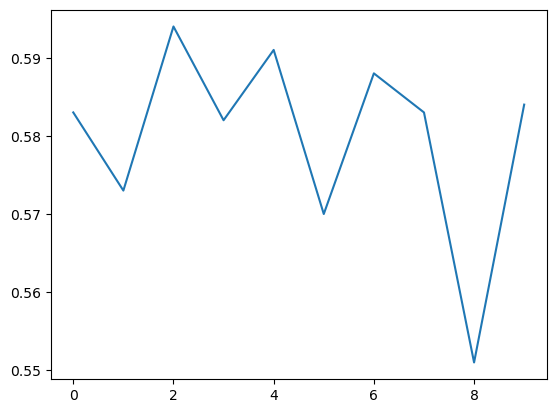

In [21]:
plt.plot(a) 

the best k for SMOTE nearest neighbor is 7

# Reinvestigating the feature selection

In [22]:
# Importing PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(X)
x_pca = pca.transform(X)

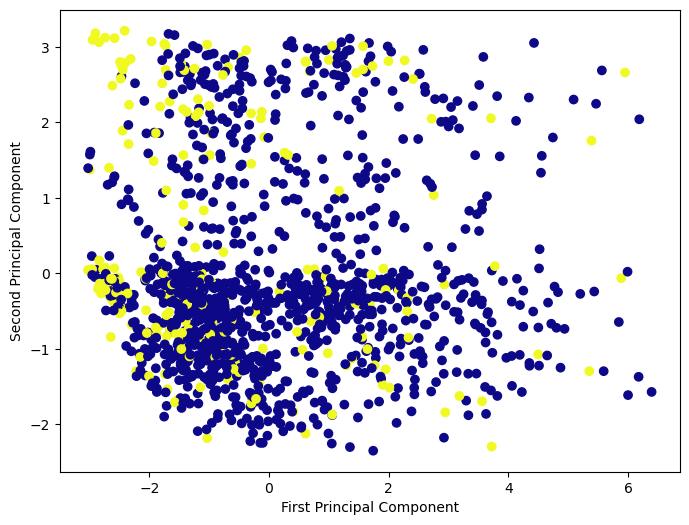

In [23]:
# giving a larger plot

################### NOT INCLUDED IN REPORT #################
plt.figure(figsize=(8, 6))

plt.scatter(x_pca[:, 0], x_pca[:, 1],
            c=y,
            cmap='plasma')

# labeling x and y axes
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.show()

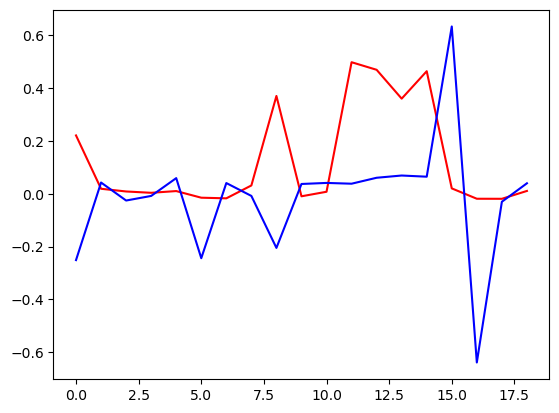

In [24]:
plt.plot(pca.components_[0],'r')
plt.plot(pca.components_[1],'b')
plt.show()

# XAI analysis 

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# Initialize the decision tree classifier
model = DecisionTreeClassifier(max_depth=3)

# Train the model
model.fit(X, y)

DecisionTreeClassifier(max_depth=3)

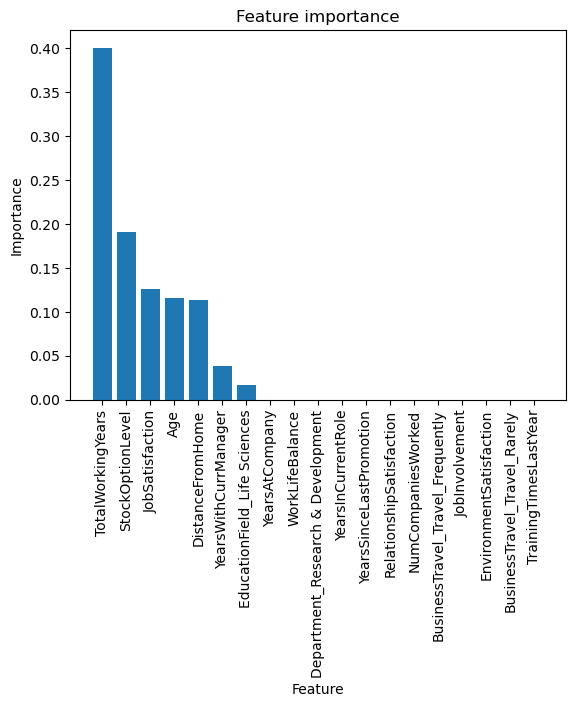

In [26]:
train_accuracy = round(model.score(X, y) * 100, 2)

# Plot the feature importances
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns
sorted_feature_names = feature_names[indices]

plt.figure()
plt.title("Feature importance")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), sorted_feature_names, rotation='vertical')
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.show()

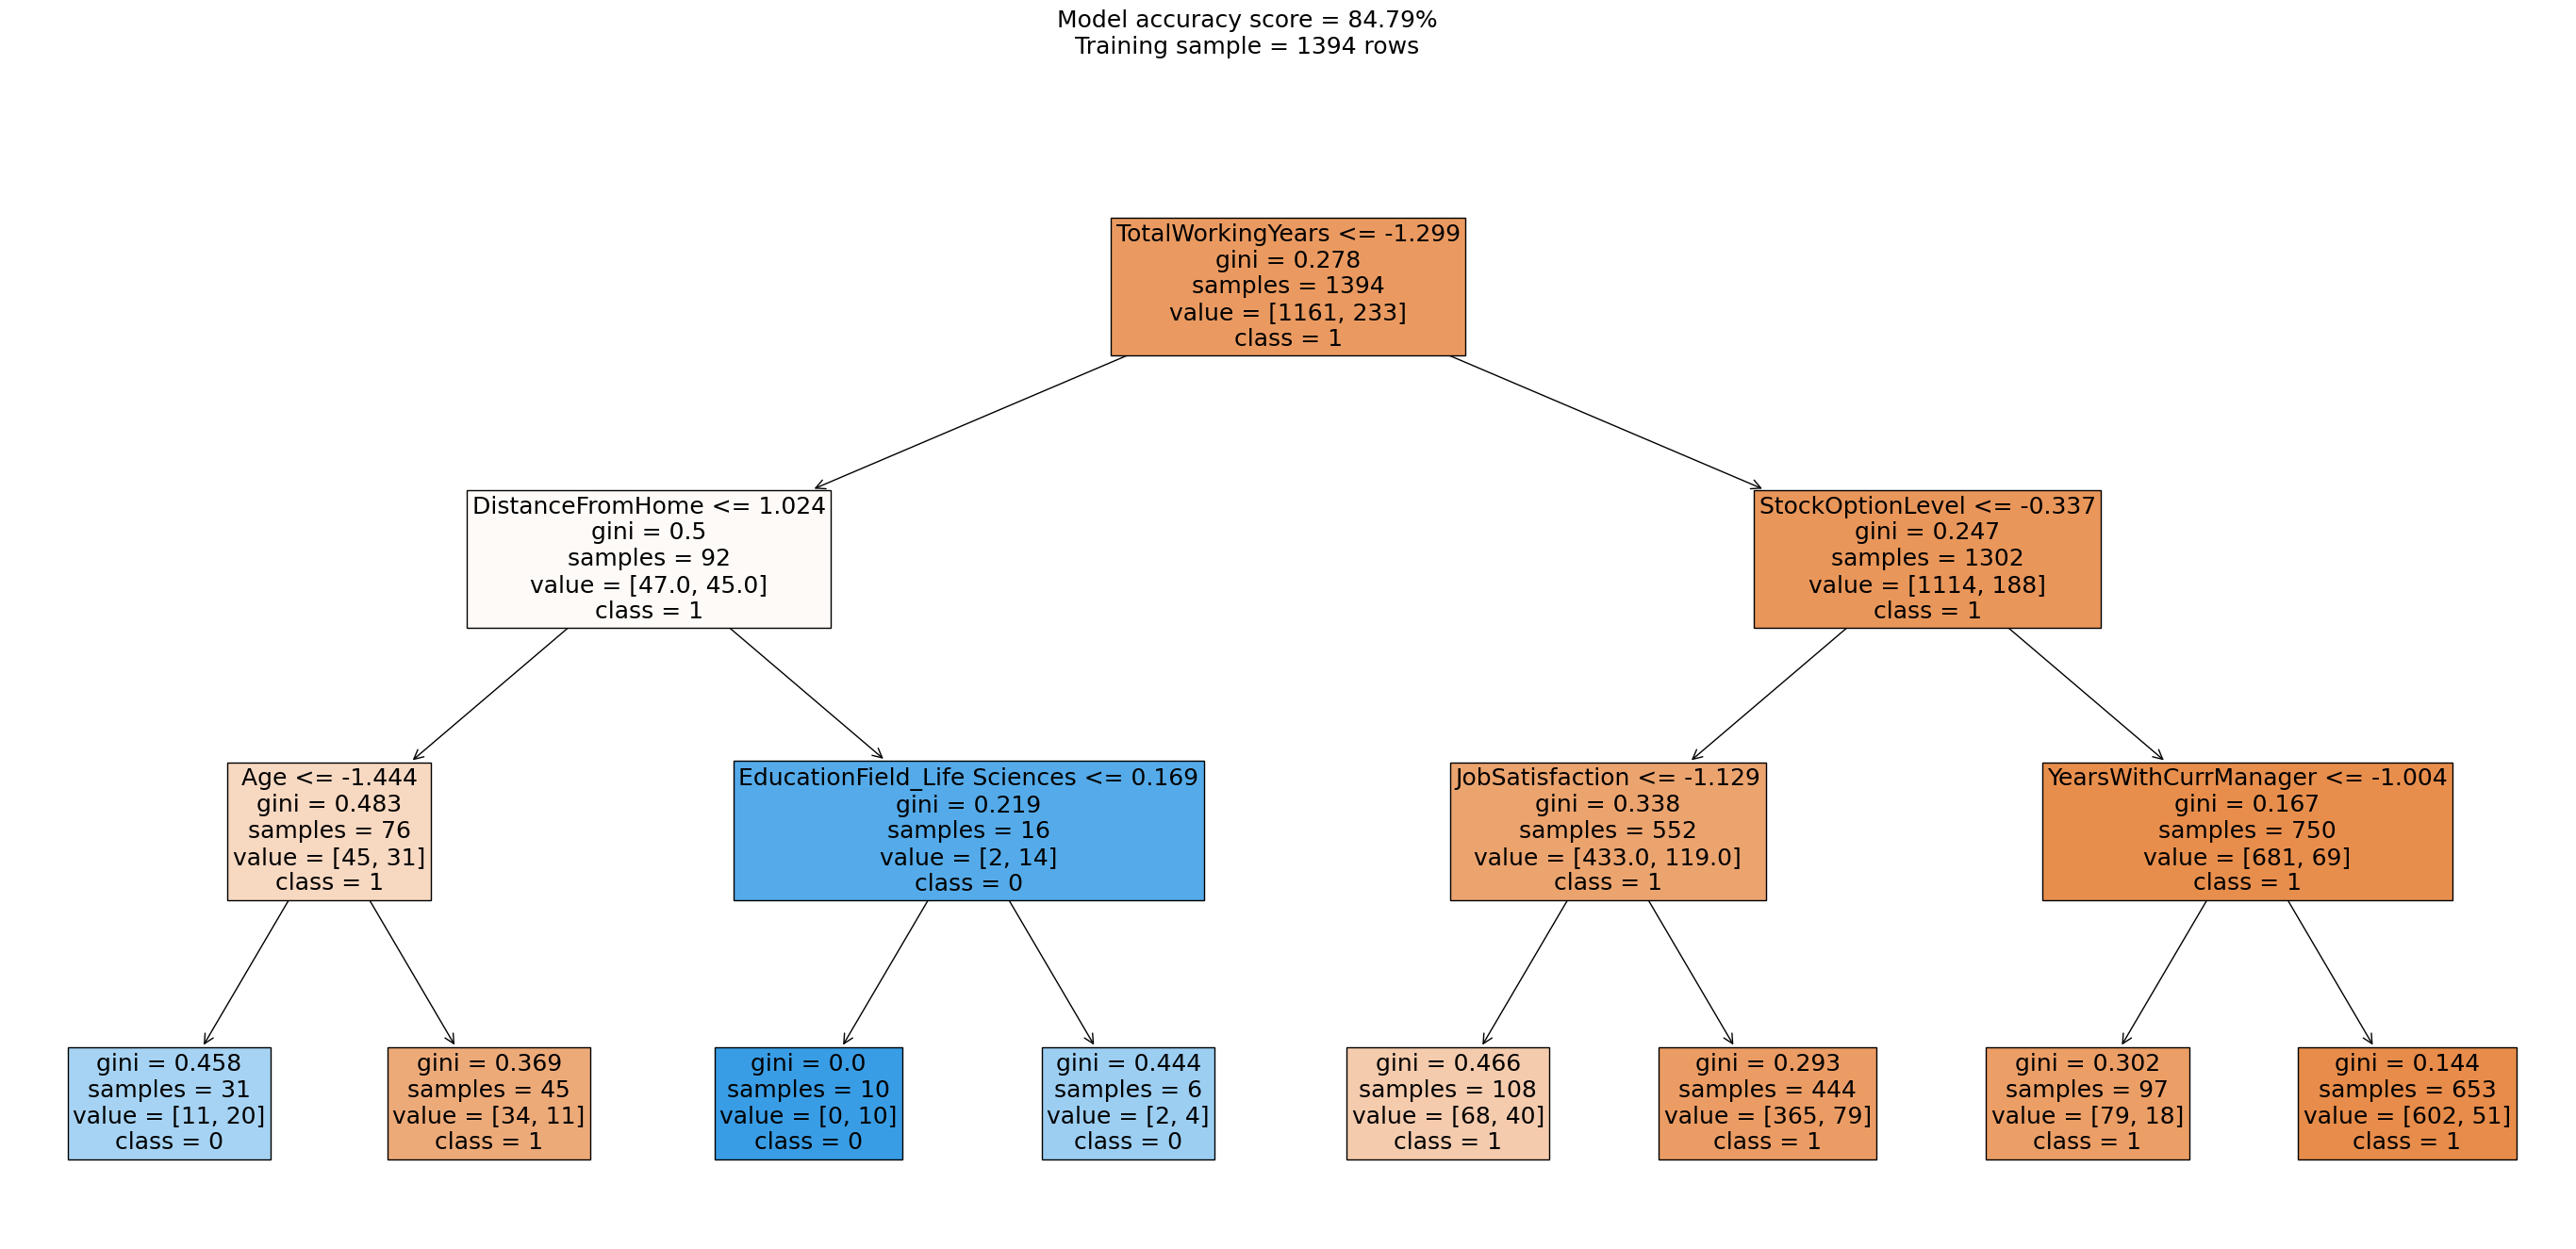

In [27]:
# Plot the decision tree 
fig = plt.figure(figsize=(35, 15))
plot = tree.plot_tree(model, 
                      feature_names=X.columns, 
                      class_names=["1","0"], 
                      filled=True,
                      fontsize=18)

plt.suptitle(f"Model accuracy score = {train_accuracy}%\nTraining sample = {len(X)} rows", 
             fontsize=18)
plt.savefig("tree.png")

In [28]:
np.unique(y)

array([0, 1], dtype=int64)

# SHAP

In [34]:
import shap
X_total = pd.read_csv("processed_hr_dataset.csv").drop("Attrition", axis=1)
explainer = shap.Explainer(svm.predict, X_total)
shap_values = explainer(X_total)

PermutationExplainer explainer: 1395it [12:25:25, 32.15s/it]                                                           


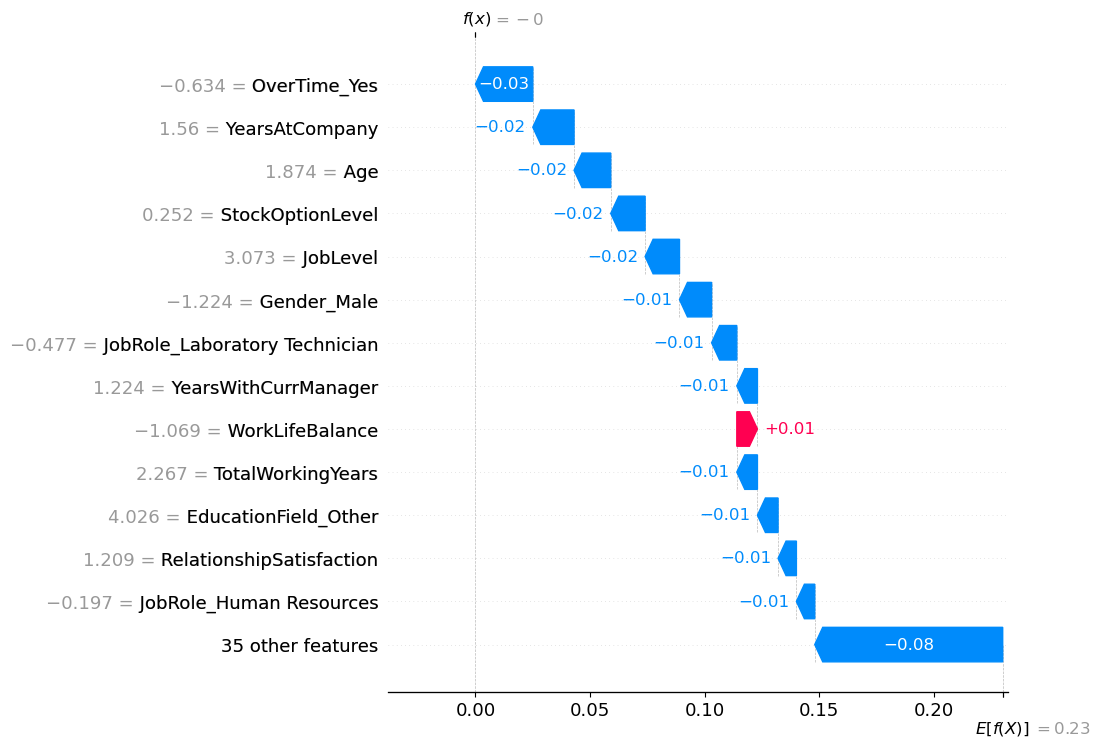

In [35]:
# the waterfall_plot shows how we get from shap_values.base_values to model.predict(X)[sample_ind]
shap.plots.waterfall(shap_values[25], max_display=14)

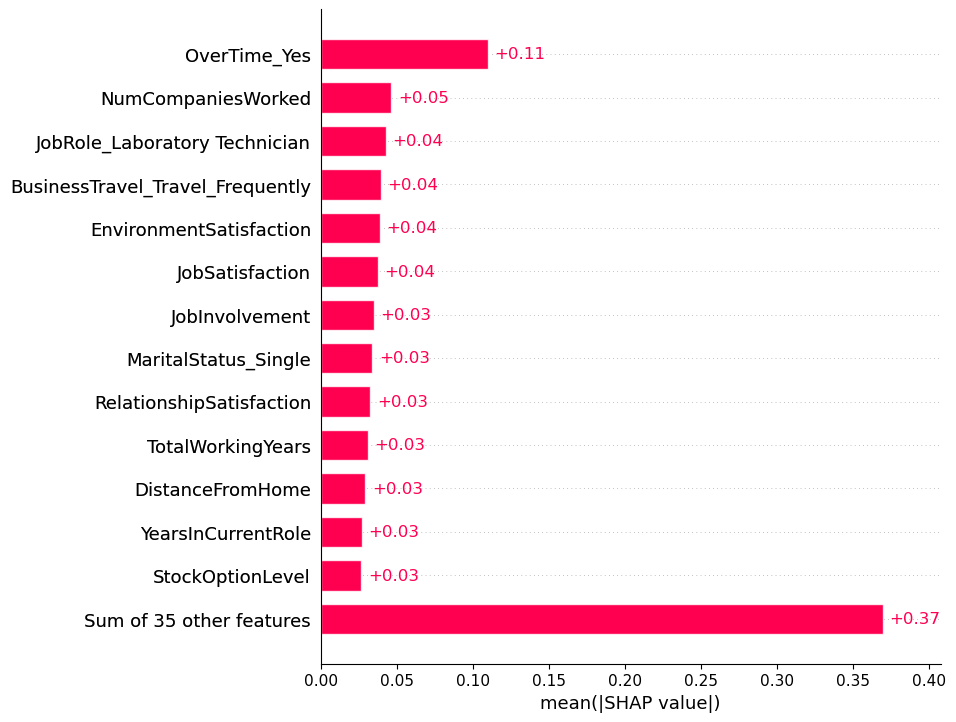

In [36]:
shap.plots.bar(shap_values, max_display=14)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13780\1197911782.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values, X_test, plot_type="bar", max_display=14)


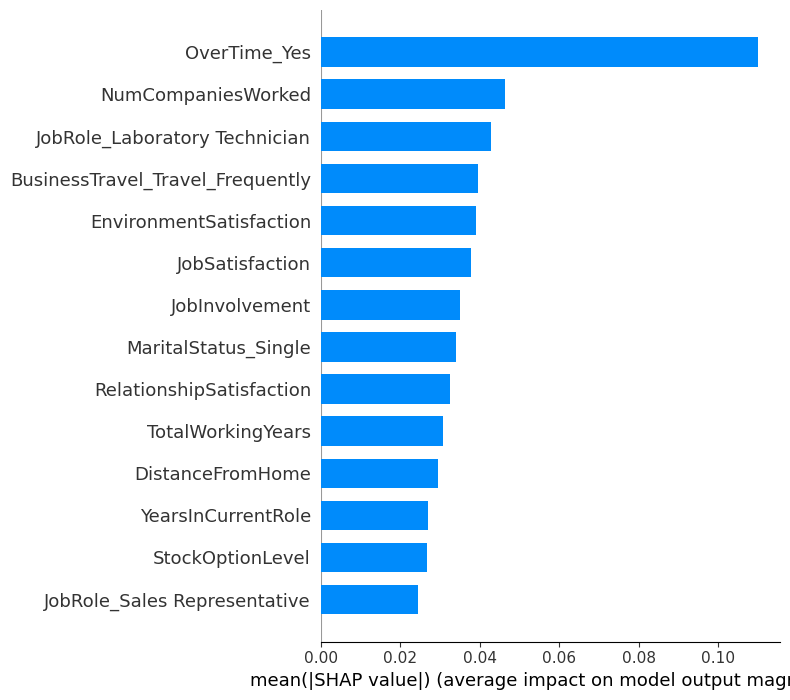

In [37]:
shap.summary_plot(shap_values.values, X_test, plot_type="bar", max_display=14)


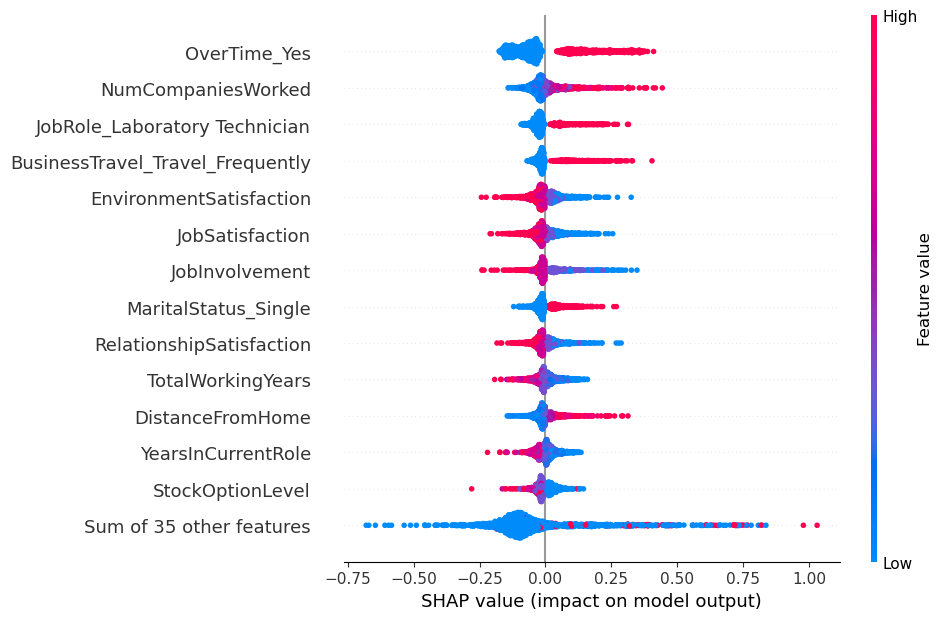

In [38]:
shap.plots.beeswarm(shap_values, max_display=14)

In [39]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_Abs_SHAP': mean_abs_shap
}).sort_values(by='Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

print("Top 10 most important features:")
print(feature_importance.head(20))

feature_importance.to_csv('shap_feature_importance.csv', index=False)
print("\n✅ 'shap_feature_importance.csv' saved.")

Top 10 most important features:
                             Feature  Mean_Abs_SHAP
0                       OverTime_Yes       0.110006
1                 NumCompaniesWorked       0.046403
2      JobRole_Laboratory Technician       0.042914
3   BusinessTravel_Travel_Frequently       0.039679
4            EnvironmentSatisfaction       0.038968
5                    JobSatisfaction       0.037739
6                     JobInvolvement       0.034989
7               MaritalStatus_Single       0.034032
8           RelationshipSatisfaction       0.032614
9                  TotalWorkingYears       0.030791
10                  DistanceFromHome       0.029394
11                YearsInCurrentRole       0.027055
12                  StockOptionLevel       0.026806
13      JobRole_Sales Representative       0.024449
14                               Age       0.022745
15                       Gender_Male       0.021321
16           YearsSinceLastPromotion       0.020537
17   EducationField_Technical De

In [40]:
file_path = 'final_selected_19_features_dataset.csv'  

df_selected = pd.read_csv(file_path)

selected_features = df_selected.columns.tolist()

print("✅ first selected features:")
print(selected_features)


✅ first selected features:
['Age', 'DistanceFromHome', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobSatisfaction', 'NumCompaniesWorked', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'EducationField_Life Sciences', 'Attrition']


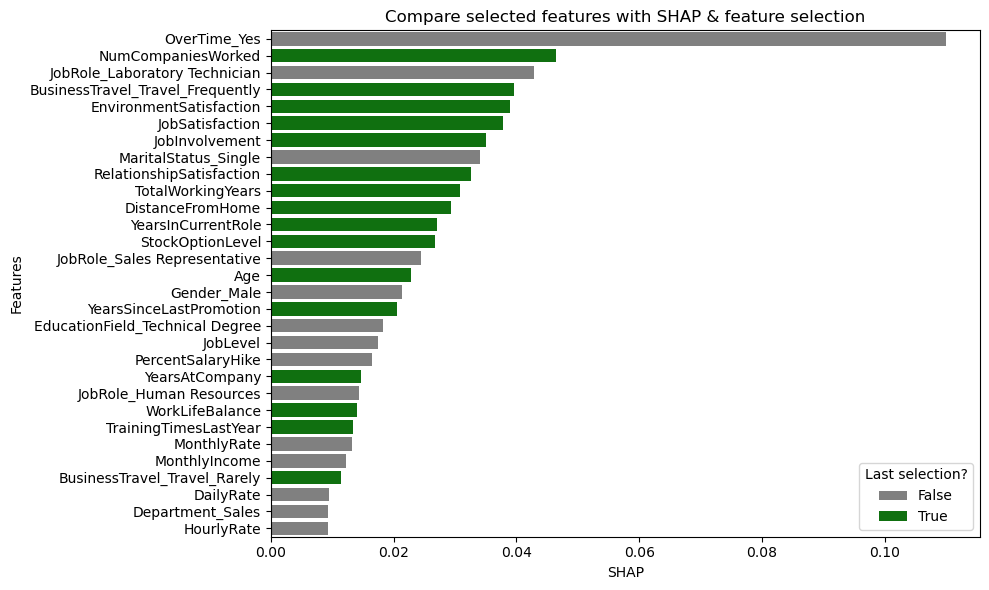

In [43]:
feature_importance['Selected'] = feature_importance['Feature'].isin(selected_features)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance.head(30),  
    x='Mean_Abs_SHAP',
    y='Feature',
    hue='Selected',
    dodge=False,
    palette={True: 'green', False: 'gray'}
)
plt.title('Compare selected features with SHAP & feature selection')
plt.xlabel('SHAP')
plt.ylabel('Features')
plt.legend(title='Last selection?')
plt.tight_layout()
plt.savefig("feature_comparison.png")
plt.show()